General program

In [12]:
# Cell 1: Import dependencies and define Core Engine with Fault Analysis Tools
import numpy as np
import re
import os
import time
import json

class DiagnosticTensorSimulator:
    def __init__(self):
        self.inputs = []
        self.outputs = []
        self.gates = {}       
        self.topo_order = []  

    def load_bench(self, file_path: str):
        self.inputs = []
        self.outputs = []
        self.gates = {}
        
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"🚨 Path '{file_path}' does not exist.")
            
        with open(file_path, 'r') as f:
            lines = [line.strip() for line in f if line.strip() and not line.startswith('#')]
        
        for line in lines:
            if line.startswith("INPUT"):
                node = re.search(r'INPUT\s*\(\s*([\w\d_-]+)\s*\)', line).group(1)
                self.inputs.append(node)
            elif line.startswith("OUTPUT"):
                node = re.search(r'OUTPUT\s*\(\s*([\w\d_-]+)\s*\)', line).group(1)
                self.outputs.append(node)
            elif "=" in line:
                out_node, expr = line.split("=")
                out_node = out_node.strip()
                gate_type, ins_raw = expr.split("(")
                gate_type = gate_type.strip().upper()
                ins = [i.strip() for i in ins_raw.replace(")", "").split(",")]
                self.gates[out_node] = (gate_type, ins)

        # Topological Sort
        all_resolved = set(self.inputs)
        remaining_gates = dict(self.gates)
        self.topo_order = []
        
        while remaining_gates:
            ready_gates = [g for g, (gt, ins) in remaining_gates.items() if all(i in all_resolved for i in ins)]
            if not ready_gates:
                raise ValueError("🚨 Feedback loop or missing dependency discovered!")
            for g in ready_gates:
                self.topo_order.append(g)
                all_resolved.add(g)
                del remaining_gates[g]

    def get_collapsed_fault_list(self):
        """
        Generates a true local equivalence-collapsed stuck-at fault list.
        Applies standard gate collapsing rules (e.g., for NAND, input SA0s collapse to output SA1).
        """
        # Start by tracking all faults we potentially want to look at
        # We use a set to automatically handle shared nets/wires smoothly
        collapsed_faults = set()
        
        # 1. Add all faults for Primary Inputs as a baseline baseline
        for pi in self.inputs:
            collapsed_faults.add((pi, "SA0"))
            collapsed_faults.add((pi, "SA1"))
            
        # 2. Iterate through every gate and apply Boolean Equivalence rules
        for gate_out, (gate_type, gate_ins) in self.gates.items():
            # Always track both faults on the gate output to cover downstream paths
            collapsed_faults.add((gate_out, "SA0"))
            collapsed_faults.add((gate_out, "SA1"))
            
            if gate_type in ["NAND", "AND"]:
                # Rule: Input SA0 faults are equivalent to Output SA0 (for AND) or Output SA1 (for NAND)
                # Therefore, we can REMOVE/COLLAPSE all input SA0 faults from our tracking list!
                for inp in gate_ins:
                    # Keep input SA1 (it is distinct), but discard input SA0
                    collapsed_faults.add((inp, "SA1"))
                    if (inp, "SA0") in collapsed_faults and inp not in self.inputs:
                        collapsed_faults.remove((inp, "SA0"))
                        
            elif gate_type in ["NOR", "OR"]:
                # Rule: Input SA1 faults are equivalent to Output SA1 (for OR) or Output SA0 (for NOR)
                # Therefore, we can REMOVE/COLLAPSE all input SA1 faults!
                for inp in gate_ins:
                    # Keep input SA0, discard input SA1
                    collapsed_faults.add((inp, "SA0"))
                    if (inp, "SA1") in collapsed_faults and inp not in self.inputs:
                        collapsed_faults.remove((inp, "SA1"))
                        
            elif gate_type == "NOT":
                # Rule: Input SA0 == Output SA1, Input SA1 == Output SA0
                # We can completely drop internal NOT inputs if they aren't PIs
                for inp in gate_ins:
                    if inp not in self.inputs:
                        collapsed_faults.discard((inp, "SA0"))
                        collapsed_faults.discard((inp, "SA1"))
            else:
                # Fallback for complex gates (XOR/XNOR) where static local collapsing doesn't apply cleanly
                for inp in gate_ins:
                    collapsed_faults.add((inp, "SA0"))
                    collapsed_faults.add((inp, "SA1"))

        # Convert back to a clean, unique sorted list of tuples
        return sorted(list(collapsed_faults))

    def simulate(self, input_vectors: np.ndarray, fault_node=None, fault_type=None) -> dict:
        num_vectors = input_vectors.shape[1]
        node_values = {}
        
        for idx, inp in enumerate(self.inputs):
            node_values[inp] = input_vectors[idx].copy()
            if fault_node == inp:
                node_values[inp] = np.zeros(num_vectors, dtype=np.uint8) if fault_type == 'SA0' else np.ones(num_vectors, dtype=np.uint8)

        for gate in self.topo_order:
            gate_type, ins = self.gates[gate]
            in_vals = [node_values[i] for i in ins]
            
            if gate_type == "NAND":
                res = ~(np.bitwise_and.reduce(in_vals)) & 1
            elif gate_type == "AND":
                res = np.bitwise_and.reduce(in_vals)
            elif gate_type == "OR":
                res = np.bitwise_or.reduce(in_vals)
            elif gate_type == "NOR":
                res = ~(np.bitwise_or.reduce(in_vals)) & 1
            elif gate_type == "XOR":
                res = np.bitwise_xor.reduce(in_vals)
            elif gate_type == "XNOR":
                res = ~(np.bitwise_xor.reduce(in_vals)) & 1
            elif gate_type == "NOT":
                res = ~in_vals[0] & 1
            elif gate_type in ["BUFF", "BUF"]:
                res = in_vals[0].copy()
            else:
                raise NotImplementedError(f"Gate type '{gate_type}' is unhandled.")
                
            if fault_node == gate:
                res = np.zeros(num_vectors, dtype=np.uint8) if fault_type == 'SA0' else np.ones(num_vectors, dtype=np.uint8)
                    
            node_values[gate] = res
            
        return {out: node_values[out] for out in self.outputs}

In [13]:
# Cell 2: Test Vector Utility Loader
def load_test_vectors(file_path: str, num_inputs: int, fallback_count=100) -> np.ndarray:
    if file_path and os.path.exists(file_path):
        vectors = []
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                binary_match = re.match(r'^([01]+)', line)
                if binary_match:
                    pi_bits = binary_match.group(1)
                    if len(pi_bits) != num_inputs:
                        raise ValueError(f"🚨 Vector bit length mismatch! Circuit expects {num_inputs} inputs.")
                    vectors.append([int(b) for b in pi_bits])
        if vectors:
            print(f"📖 Successfully loaded {len(vectors)} test vectors from '{file_path}'.")
            return np.array(vectors, dtype=np.uint8).T
            
    print(f"⚠️ File '{file_path}' not found. Generating {fallback_count} random patterns dynamically...")
    np.random.seed(42)
    return np.random.randint(0, 2, size=(num_inputs, fallback_count), dtype=np.uint8)

In [14]:
# Cell 3: Automated Diagnostic Batch Testing & Log Generator
def run_automated_fault_assessment(circuit, input_matrix, log_filename="fault_simulation_diagnostics.log"):
    """
    Executes all collapsed faults, benchmarks evaluation time, 
    gathers advanced diagnostic metrics, and streams results to a structured log file.
    """
    # 1. Acquire Golden Reference Output
    golden_outputs = circuit.simulate(input_matrix)
    total_vectors = input_matrix.shape[1]
    
    # 2. Get unique checkpoint faults
    fault_list = circuit.get_collapsed_fault_list()
    print(f"🔬 Total unique collapsed faults to analyze: {len(fault_list)}")
    
    log_entries = []
    detected_faults_count = 0
    
    print(f"✍️ Simulating and writing records directly to: '{log_filename}'...")
    bench_start=time.perf_counter()
    with open(log_filename, "w") as log_file:
        # Write header line
        log_file.write("# === VLSI TENSOR SIMULATION DIAGNOSTIC REPORT ===\n")
        log_file.write(f"# Timestamp: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        log_file.write(f"# Total Test Vectors Evaluated: {total_vectors}\n")
        log_file.write(f"# Total PIs count: {len(circuit.inputs)},list of PIs:{circuit.inputs}\n")
        log_file.write(f"# Total POs count: {len(circuit.outputs)},list of POS: {circuit.outputs}\n")
        log_file.write(f"# Total fault list count: {len(fault_list)},list of fault list: {fault_list}\n\n")
        
        for f_node, f_type in fault_list:
            # Benchmark precisely using high-resolution performance timers
            start_time = time.perf_counter()
            faulty_outputs = circuit.simulate(input_matrix, fault_node=f_node, fault_type=f_type)
            end_time = time.perf_counter()
            
            duration_microseconds = (end_time - start_time) * 1_000_000
            
            # Metric Discovery: Compute detection vectors
            detection_mask = np.zeros(total_vectors, dtype=bool)
            corrupted_pos = []
            hamming_distance_per_po = {}
            
            for out in circuit.outputs:
                mismatch_mask = (golden_outputs[out] != faulty_outputs[out])
                detection_mask |= mismatch_mask
                
                mismatch_count = int(np.sum(mismatch_mask))
                if mismatch_count > 0:
                    corrupted_pos.append(out)
                    hamming_distance_per_po[out] = mismatch_count
            
            is_detected = bool(np.any(detection_mask))
            detect_indices = np.where(detection_mask)[0].tolist()
            
            if is_detected:
                detected_faults_count += 1
                
            # Build an enriched diagnostic payload record
            diagnostic_record = {
                "fault_node": f_node,
                "fault_type": f_type,
                "status": "DETECTED" if is_detected else "UNDETECTED",
                "duration_us": round(duration_microseconds, 8),
                "total_detecting_vectors": len(detect_indices),
                "detecting_vector_indices": detect_indices,
                "corrupted_primary_outputs": corrupted_pos,
                "output_mismatch_counts": hamming_distance_per_po, #sum of all results where golder po <> fault po
                "raw_golden_po": {out: golden_outputs[out].tolist() for out in circuit.outputs},
                "raw_faulty_po": {out: faulty_outputs[out].tolist() for out in circuit.outputs}
            }
            
            # Write row directly to disk as JSON string lines for easy streaming parsing later
            log_file.write(json.dumps(diagnostic_record) + "\n")
            log_entries.append(diagnostic_record)
        bench_end=time.perf_counter()
        duration_bench_us = (bench_end - bench_start) * 1_000_000
        log_file.write(f"{'*'*100}\nCoverage: {(detected_faults_count / len(fault_list)) * 100}%\n")
        log_file.write(f"{'*'*100}\nTotal time: {duration_bench_us}")
    # Calculate Summary Stats
    coverage = (detected_faults_count / len(fault_list)) * 100
    print(f"🎉 Analysis Complete! Overall Fault Coverage: {coverage:.2f}%")
    return log_entries

In [15]:
# Cell 4: Production Run
# BENCH_PATH = "./data.nogit/c17.bench"
# VECTOR_PATH = "./data.nogit/c17.tests"
# LOG_PATH = "./logs/c17_diagnostics_report.log"
def benchmark(bench,test,log):
    # Initialize and run
    circuit = DiagnosticTensorSimulator()
    circuit.load_bench(bench)

    input_matrix = load_test_vectors(test, num_inputs=len(circuit.inputs), fallback_count=100)

    # Run full evaluation
    records = run_automated_fault_assessment(circuit, input_matrix, log_filename=log)

    # # Preview the first log record inside your notebook display
    # print("\n👀 Sample JSON Log Entry Preview (First Fault Tested):")
    # print(json.dumps(records[0], indent=4))

In [7]:
# Cell 4: Production Run
BENCH_PATH = "./data.nogit/c6288.bench"
VECTOR_PATH = "./data.nogit/c6288.tests"
LOG_PATH = "./logs/c6288_diagnostics_report.log"
benchmark(BENCH_PATH,VECTOR_PATH,LOG_PATH)

📖 Successfully loaded 100 test vectors from './data.nogit/c6288.tests'.


In [ ]:
import os
bench_file=[]
test_file=[]
log_file=[]
for a in os.listdir('./data.nogit/'):
    if ".bench" in a:
        bench_file.append('./data.nogit/'+a)
        log_file.append('./logs/'+a.split('.')[0]+'_report.log')
    else:
        test_file.append('./data.nogit/'+a)
bench_file.sort()
test_file.sort()
log_file.sort()

for a,b,c in zip(bench_file,test_file,log_file):
    print(a,'\t',b,'\t',c)
    try:
        benchmark(a,b,c)
    except:
        print(f"{a} failed, pending to run benchmark again")

./data.nogit/c1355.bench 	 ./data.nogit/c1355.tests 	 ./logs/c1355_report.log
📖 Successfully loaded 100 test vectors from './data.nogit/c1355.tests'.
🔬 Total unique collapsed faults to analyze: 692
✍️ Simulating and writing records directly to: './logs/c1355_report.log'...
./data.nogit/c1355.bench failed, pending to run benchmark again
./data.nogit/c17.bench 	 ./data.nogit/c17.tests 	 ./logs/c17_report.log
📖 Successfully loaded 100 test vectors from './data.nogit/c17.tests'.
🔬 Total unique collapsed faults to analyze: 18
✍️ Simulating and writing records directly to: './logs/c17_report.log'...
🎉 Analysis Complete! Overall Fault Coverage: 100.00%
./data.nogit/c1908.bench 	 ./data.nogit/c1908.tests 	 ./logs/c1908_report.log
📖 Successfully loaded 100 test vectors from './data.nogit/c1908.tests'.
🔬 Total unique collapsed faults to analyze: 948
✍️ Simulating and writing records directly to: './logs/c1908_report.log'...
🎉 Analysis Complete! Overall Fault Coverage: 82.49%
./data.nogit/c2670.b

In [ ]:
BENCH_PATH = "./data.nogit/c17.bench"
VECTOR_PATH = "./data.nogit/c17.tests"
LOG_PATH = "./logs/c17_diagnostics_report.log"
benchmark(BENCH_PATH,VECTOR_PATH,LOG_PATH)

📖 Successfully loaded 100 test vectors from './data.nogit/c17.tests'.
🔬 Total unique collapsed faults to analyze: 18
✍️ Simulating and writing records directly to: './logs/c17_diagnostics_report.log'...
🎉 Analysis Complete! Overall Fault Coverage: 100.00%


In [1]:
import json
import os
import re

def generate_summary_from_header(log_filepath, bench_name="Circuit"):
    """
    Parses metadata directly from the structured log file header,
    then aggregates runtime and fault coverage data from the log body.
    """
    if not os.path.exists(log_filepath):
        print(f"🚨 Log file '{log_filepath}' not found.")
        return None

    # Header tracking elements
    pi_count = 0
    po_count = 0
    fault_list_count = 0
    
    # Body calculations
    detected_faults = 0
    cumulative_time_us = 0.0

    with open(log_filepath, "r") as f:
        for line in f:
            line = line.strip()
            
            # 1. Parse Metadata Metrics out of the Header Comments
            if line.startswith("#"):
                if "Total PIs count:" in line:
                    match = re.search(r'Total PIs count:\s*(\d+)', line)
                    if match: pi_count = int(match.group(1))
                elif "Total POs count:" in line:
                    match = re.search(r'Total POs count:\s*(\d+)', line)
                    if match: po_count = int(match.group(1))
                elif "Total fault list count:" in line:
                    match = re.search(r'Total fault list count:\s*(\d+)', line)
                    if match: fault_list_count = int(match.group(1))
                continue
                
            # 2. Parse Execution Records from the Data Rows
            if not line:
                continue
                
            try:
                record = json.loads(line)
                cumulative_time_us += record.get("duration_us", 0.0)
                if record.get("status") == "DETECTED":
                    detected_faults += 1
            except json.JSONDecodeError:
                continue

    # Final Metric Balancing Calculations
    fault_coverage = (detected_faults / fault_list_count * 100) if fault_list_count > 0 else 0.0
    total_time_ms = cumulative_time_us / 1000.0
    properties_str = f"{pi_count} PIs / {po_count} POs"
    
    # Build cleanly formatted ASCII Output Block
    header_str = f"| {'Circuit':<12} | {'Properties':<16} | {'Fault List Count':<18} | {'Total Time':<14} | {'Fault Coverage':<14} |"
    divider = "+" + "-"*14 + "+" + "-"*18 + "+" + "-"*20 + "+" + "-"*16 + "+" + "-"*16 + "+"
    #row_str = f"| {bench_name:<12} | {properties_str:<16} | {fault_list_count:<18} | {total_time_ms:.2f} ms:<14}| {fault_coverage:.2f}%:<14} |"
    
    # Correct string slicing for uniform row cells
    row_str = f"| {bench_name:<12} | {properties_str:<16} | {fault_list_count:<18} | {f'{total_time_ms:.2f} ms':<14} | {f'{fault_coverage:.2f}%':<14} |"

    print("\n📊 === VLSI FAULT SIMULATION BASELINE SUMMARY ===")
    print(divider)
    print(header_str)
    print(divider)
    print(row_str)
    print(divider)

In [3]:
import re
import time
import torch

class BenchCircuitParser:
    def __init__(self, bench_file_path: str, device: str = None):
        """
        Initializes the VLSI Bench Parser and compiles structural gates into dense 
        Torch Tensors for high-throughput parallel CPU/GPU logic and fault simulations.
        
        :param bench_file_path: Path to the target .bench netlist file.
        :param device: 'cuda' for GPU acceleration, 'cpu' for standard tensor layout. 
                       Defaults to auto-detecting CUDA availability.
        """
        self.file_path = bench_file_path
        self.t0 = time.perf_counter()
        
        # Select device automatically if not specified
        if device is None:
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = device
            
        # Core structural attributes
        self.primary_inputs = []
        self.primary_outputs = []
        self.gates = {}             
        self.circuit = []           
        self.signals = {}           
        self.all_signals = []       
        self.collapsed_faults = []  
        
        # Numerical Indexing Maps for Tensor Compilation
        self.signal_to_idx = {}
        self.idx_to_signal = {}
        self.tensor_layers = []  # List of dicts containing compiled evaluation layers
        
        # Diagnostics
        self.fanout_stems = 0
        self.gate_inputs = 0
        
        # Pipeline execution
        self._parse_bench_file()
        self._insert_fanout_buffers()
        self._compute_topological_order()
        self._generate_signals_map()
        self._run_fault_equivalence()
        
        # High-Performance Tensor Matrix compilation stage
        self._compile_to_tensors()
        self._print_summary()

    def log(self, msg: str):
        print(f"# {time.perf_counter() - self.t0:09.3f} - {msg}")

    def _parse_line(self, line: str):
        line = line.strip()
        if "=" not in line:
            return None
        try:
            output_part, gate_part = line.split("=", 1)
            output_signal = output_part.strip()
            match = re.match(r"^\s*([A-Za-z0-9_]+)\s*\((.*)\)\s*$", gate_part.strip())
            if match:
                gate_type = match.group(1).upper()
                inputs = [i.strip() for i in match.group(2).split(",") if i.strip()]
                return output_signal, gate_type, inputs
        except Exception:
            pass
        return None

    def _parse_bench_file(self):
        self.log(f"Parsing file: {self.file_path}")
        with open(self.file_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#"):
                    continue
                if line.startswith("INPUT("):
                    pi = line[6:line.index(")")].strip()
                    self.primary_inputs.append(pi)
                    continue
                if line.startswith("OUTPUT("):
                    po = line[7:line.index(")")].strip()
                    self.primary_outputs.append(po)
                    continue
                parsed = self._parse_line(line)
                if parsed:
                    out_sig, g_type, in_sigs = parsed
                    self.gates[out_sig] = {"type": g_type, "inputs": in_sigs}

    def _insert_fanout_buffers(self):
        consumption_counts = {}
        for out_sig, gate_info in list(self.gates.items()):
            for inp in gate_info["inputs"]:
                if inp not in consumption_counts:
                    consumption_counts[inp] = []
                consumption_counts[inp].append(out_sig)
        
        for src_signal, consumer_gates in consumption_counts.items():
            if len(consumer_gates) > 1:
                self.fanout_stems += 1
                for idx, consumer_gate in enumerate(consumer_gates):
                    buffer_out = f"{src_signal}.b{idx}"
                    self.gates[buffer_out] = {"type": "BUFF", "inputs": [src_signal]}
                    target_inputs = self.gates[consumer_gate]["inputs"]
                    for i_idx, inp in enumerate(target_inputs):
                        if inp == src_signal:
                            target_inputs[i_idx] = buffer_out

    def _compute_topological_order(self):
        in_degree = {gate: len(info["inputs"]) for gate, info in self.gates.items()}
        signal_to_gates = {}
        for gate, info in self.gates.items():
            for inp in info["inputs"]:
                if inp not in signal_to_gates:
                    signal_to_gates[inp] = []
                signal_to_gates[inp].append(gate)
                
        ready_queue = list(self.primary_inputs)
        ordered_gates = []
        
        # Track gate groups layer-by-layer for concurrent tensor executions
        self.layer_groups = []
        
        # Primary inputs form virtual baseline Layer 0
        current_layer = []
        next_layer = []
        
        while ready_queue or current_layer:
            if not current_layer:
                current_layer = list(ready_queue)
                ready_queue.clear()
                if not current_layer:
                    break
            
            curr = current_layer.pop(0)
            if curr in signal_to_gates:
                for dependent_gate in signal_to_gates[curr]:
                    in_degree[dependent_gate] -= 1
                    if in_degree[dependent_gate] == 0:
                        next_layer.append(dependent_gate)
                        ordered_gates.append(dependent_gate)
            
            if not current_layer and next_layer:
                self.layer_groups.append(list(next_layer))
                ready_queue.extend(next_layer)
                next_layer.clear()

        self.circuit = []
        for gate in ordered_gates:
            g_type = self.gates[gate]["type"]
            g_inps = ", ".join(self.gates[gate]["inputs"])
            self.circuit.append(f"{gate} = {g_type}({g_inps})")

    def _generate_signals_map(self):
        for gate_str in self.circuit:
            parsed = self._parse_line(gate_str)
            if parsed:
                out_sig, _, in_sigs = parsed
                for inp in in_sigs:
                    if inp not in self.signals:
                        self.signals[inp] = []
                    self.signals[inp].append(gate_str)
        self.all_signals = list(self.signals.keys())

    def _run_fault_equivalence(self):
        collapsed_set = set()
        equivalences = set()
        not_gates = []
        
        for gate_str in reversed(self.circuit):
            parsed = self._parse_line(gate_str)
            if not parsed: continue
            out_sig, gate_type, in_sigs = parsed
            
            if gate_type != "BUFF":
                self.gate_inputs += len(in_sigs)
            if out_sig in self.primary_outputs:
                collapsed_set.add(f"{out_sig}@0")
                collapsed_set.add(f"{out_sig}@1")
                
            match gate_type:
                case "AND" | "NAND":
                    for inp in in_sigs:
                        collapsed_set.add(f"{inp}@1")
                        equivalences.add(f"{inp}@0")
                case "OR" | "NOR":
                    for inp in in_sigs:
                        collapsed_set.add(f"{inp}@0")
                        equivalences.add(f"{inp}@1")
                case _:
                    if gate_type == "NOT":
                        not_gates.append(gate_str)
                    for inp in in_sigs:
                        collapsed_set.add(f"{inp}@0")
                        collapsed_set.add(f"{inp}@1")
                        
        for gate_str in not_gates:
            parsed = self._parse_line(gate_str)
            if parsed:
                out_sig, _, in_sigs = parsed
                for val in ["0", "1"]:
                    fault_str = f"{out_sig}@{val}"
                    inverted_val = str(abs(1 - int(val)))
                    if fault_str in equivalences or fault_str in collapsed_set:
                        for inp in in_sigs:
                            collapsed_set.discard(f"{inp}@{inverted_val}")

        self.collapsed_faults = sorted(list(collapsed_set))

    def _compile_to_tensors(self):
        """
        Phase 5: Matrix Tensor Compilation Strategy.
        Transforms names into fixed index coordinates, structures gate execution types 
        into discrete numerical opcodes, and constructs parallel processing layers.
        """
        self.log(f"Compiling circuit topology to PyTorch device tensor arrays ({self.device})...")
        
        # Build global structural indexing records
        all_net_signals = set(self.primary_inputs) | set(self.primary_outputs) | set(self.gates.keys())
        for idx, sig in enumerate(sorted(list(all_net_signals))):
            self.signal_to_idx[sig] = idx
            self.idx_to_signal[idx] = sig
            
        self.total_signal_count = len(self.signal_to_idx)
        
        # Opcode assignments
        op_map = {"BUFF": 0, "NOT": 1, "AND": 2, "NAND": 3, "OR": 4, "NOR": 5, "XOR": 6, "XNOR": 7}
        
        # Structure the layout using evaluation layer vectors
        self.tensor_layers = []
        for layer in self.layer_groups:
            if not layer: continue
            
            # Find the maximum fan-in across this group to establish stable tensor column widths
            max_inputs = max(len(self.gates[gate]["inputs"]) for gate in layer)
            
            layer_outputs = []
            layer_opcodes = []
            layer_inputs = []
            
            for gate in layer:
                g_info = self.gates[gate]
                layer_outputs.append(self.signal_to_idx[gate])
                layer_opcodes.append(op_map.get(g_info["type"], 0))
                
                # Convert inputs to their absolute signal indices (pad with 0 if fewer inputs exist)
                in_idxs = [self.signal_to_idx[inp] for inp in g_info["inputs"]]
                while len(in_idxs) < max_inputs:
                    in_idxs.append(0) 
                layer_inputs.append(in_idxs)
                
            # Convert raw structural lists into native, compiled PyTorch device tensors
            self.tensor_layers.append({
                "outputs": torch.tensor(layer_outputs, dtype=torch.long, device=self.device),
                "opcodes": torch.tensor(layer_opcodes, dtype=torch.uint8, device=self.device),
                "inputs": torch.tensor(layer_inputs, dtype=torch.long, device=self.device)
            })
            
        self.log(f"Successfully compiled {len(self.tensor_layers)} parallel hardware processing layers.")

    def simulate_vectors(self, input_tensor: torch.Tensor) -> torch.Tensor:
        """
        Executes a highly parallel forward logic simulation across all inputs simultaneously.
        
        :param input_tensor: A Boolean PyTorch tensor of shape (num_test_vectors, num_primary_inputs)
        :return: An evaluation state matrix mapping output values
        """
        num_vectors = input_tensor.shape[0]
        
        # Initialize full circuit simulation state tracking matrix
        # Shape: (num_test_vectors, total_circuit_signals)
        state_tensor = torch.zeros((num_vectors, self.total_signal_count), dtype=torch.bool, device=self.device)
        
        # Map primary input test states into the tracking matrix simultaneously
        pi_indices = [self.signal_to_idx[pi] for pi in self.primary_inputs]
        state_tensor[:, pi_indices] = input_tensor.to(self.device)
        
        # Sequentially step through parallel computation layers
        for layer in self.tensor_layers:
            out_idx = layer["outputs"]
            opcodes = layer["opcodes"]
            in_idx = layer["inputs"]
            
            # Use advanced index gathering to pull the states of all inputs simultaneously
            # Shape: (num_vectors, num_gates_in_layer, fan_in)
            gathered_inputs = state_tensor[:, in_idx]
            
            # Process gate behaviors across all input vectors simultaneously using tensor logic functions
            for i in range(len(out_idx)):
                op = opcodes[i]
                g_out = out_idx[i]
                g_inps = gathered_inputs[:, i, :] # Inputs for this specific gate across all vectors
                
                if op == 0:    # BUFF
                    state_tensor[:, g_out] = g_inps[:, 0]
                elif op == 1:  # NOT
                    state_tensor[:, g_out] = ~g_inps[:, 0]
                elif op == 2:  # AND
                    state_tensor[:, g_out] = torch.all(g_inps, dim=-1)
                elif op == 3:  # NAND
                    state_tensor[:, g_out] = ~torch.all(g_inps, dim=-1)
                elif op == 4:  # OR
                    state_tensor[:, g_out] = torch.any(g_inps, dim=-1)
                elif op == 5:  # NOR
                    state_tensor[:, g_out] = ~torch.any(g_inps, dim=-1)
                elif op == 6:  # XOR
                    state_tensor[:, g_out] = torch.bitwise_xor(g_inps[:, 0], g_inps[:, 1])
                elif op == 7:  # XNOR
                    state_tensor[:, g_out] = ~torch.bitwise_xor(g_inps[:, 0], g_inps[:, 1])

        # Extract values for the primary output nodes
        po_indices = [self.signal_to_idx[po] for po in self.primary_outputs]
        return state_tensor[:, po_indices]

    def _print_summary(self):
        all_possible_faults = len(self.signals) * 2 + len(self.primary_outputs) * 2
        print("*" * 100)
        print(f"Target Compute Device: {self.device.upper()}")
        print(f"# of PIs:              {len(self.primary_inputs)}")
        print(f"# of POs:              {len(self.primary_outputs)}")
        print(f'# of gates:            {len(self.gates)}')
        print(f"# of fanout stems:     {self.fanout_stems}")
        print(f"# of gate inputs:      {self.gate_inputs}")
        print(f"All possible faults:   {all_possible_faults}")
        print(f"Calculated collapsed:  {len(self.collapsed_faults)}")
        print(f"Time taken:            {(time.perf_counter() - self.t0):09.3f} seconds")
        print("*" * 100)

/usr/local/python/3.12.1/lib/python3.12/site-packages/torch/_subclasses/functional_tensor.py:368: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


In [4]:
# =====================================================================
# Verification Execution Block
# =====================================================================
if __name__ == "__main__":
    parser = BenchCircuitParser("./data.nogit/c17.bench")
    
    # Example: Simulating 10,000 independent input vectors simultaneously on the GPU/CPU
    # num_pi = len(parser.primary_inputs)
    # random_test_patterns = torch.randint(0, 2, (10000, num_pi), dtype=torch.bool)
    
    # Parallel forward simulation pass across all vectors
    # output_results = parser.simulate_vectors(random_test_patterns)
    # print("Simulation Results Matrix Shape:", output_results.shape)
    pass

# 00000.008 - Parsing file: ./data.nogit/c17.bench
# 00000.012 - Compiling circuit topology to PyTorch device tensor arrays (cpu)...
# 00000.139 - Successfully compiled 6 parallel hardware processing layers.
****************************************************************************************************
Target Compute Device: CPU
# of PIs:              5
# of POs:              2
# of gates:            12
# of fanout stems:     3
# of gate inputs:      12
All possible faults:   34
Calculated collapsed:  22
Time taken:            00000.143 seconds
****************************************************************************************************


Getting circuit stats

In [1]:
# c880 basic circuit statistics
import re

def stats(filename="c880.bench"):
    inputs, outputs, gates, signals, buffers = set(), set(), {}, set(), 0

    with open(filename) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            # Primary inputs / outputs
            m = re.match(r"INPUT\((\w+)\)", line)
            if m:
                inputs.add(m.group(1))
                signals.add(m.group(1))
                continue

            m = re.match(r"OUTPUT\((\w+)\)", line)
            if m:
                outputs.add(m.group(1))
                signals.add(m.group(1))
                continue

            # Gate definition: node = TYPE(inputs...)
            m = re.match(r"(\w+)\s*=\s*(\w+)\(([^)]*)\)", line)
            if m:
                node, gate, fanins = m.groups()
                gates[node] = gate
                signals.add(node)
                signals.update(x.strip() for x in fanins.split(","))

                if gate.upper() == "BUFF":
                    buffers += 1

    print(f"ISCAS {filename} Statistics")
    print("-" * 28)
    print(f"Primary Inputs : {len(inputs)}")
    print(f"Primary Outputs: {len(outputs)}")
    print(f"Gates          : {len(gates)}")
    print(f"Signals        : {len(signals)}")
    print(f"Buffers        : {buffers}")

In [2]:
stats("./data.nogit/c17.bench")


ISCAS ./data.nogit/c17.bench Statistics
----------------------------
Primary Inputs : 5
Primary Outputs: 2
Gates          : 6
Signals        : 11
Buffers        : 0


In [5]:
# PO → PI Signal Tree
import re
from collections import defaultdict

def show_po_to_pi_tree(filename="c880.bench"):
    fanin = defaultdict(list)
    inputs, outputs = [], []

    with open(filename) as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            # Primary input
            m = re.match(r"INPUT\((\w+)\)", line)
            if m:
                inputs.append(m.group(1))
                continue

            # Primary output
            m = re.match(r"OUTPUT\((\w+)\)", line)
            if m:
                outputs.append(m.group(1))
                continue

            # signal = GATE(input1, input2, ...)
            m = re.match(r"(\w+)\s*=\s*\w+\(([^)]*)\)", line)
            if m:
                signal, fanins = m.groups()
                fanin[signal] = [
                    x.strip() for x in fanins.split(",")
                ]

    def print_tree(signal, prefix="", path=None, is_last=True):
        if path is None:
            path = set()

        print(signal)

        # Stop at PI
        if signal in inputs:
            return

        # Prevent cyclic traversal
        if signal in path:
            return

        new_path = path | {signal}
        children = fanin.get(signal, [])

        for i, child in enumerate(children):
            last = (i == len(children) - 1)
            branch = "└── " if last else "├── "
            continuation = "    " if last else "│   "

            print(prefix + branch, end="")
            print_tree(
                child,
                prefix + continuation,
                new_path,
                last
            )

    print("ISCAS c880 : PO → PI Signal Tree")
    print("=" * 50)

    for po in outputs:
        print(f"\n{po}")
        children = fanin.get(po, [])

        for i, child in enumerate(children):
            last = (i == len(children) - 1)
            branch = "└── " if last else "├── "
            continuation = "    " if last else "│   "

            print(branch, end="")
            print_tree(
                child,
                continuation,
                {po},
                last
            )

In [6]:
def save_po_to_pi_tree_md(filename="c880.bench",
                          output_file="c880_po_to_pi_tree.md"):

    fanin = defaultdict(list)
    inputs, outputs = [], []

    with open(filename) as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            m = re.match(r"INPUT\((\w+)\)", line)
            if m:
                inputs.append(m.group(1))
                continue

            m = re.match(r"OUTPUT\((\w+)\)", line)
            if m:
                outputs.append(m.group(1))
                continue

            m = re.match(r"(\w+)\s*=\s*\w+\(([^)]*)\)", line)
            if m:
                signal, fanins = m.groups()
                fanin[signal] = [x.strip() for x in fanins.split(",")]

    def write_tree(signal, file, prefix="", path=None):
        if path is None:
            path = set()

        file.write(signal + "\n")

        if signal in inputs or signal in path:
            return

        new_path = path | {signal}
        children = fanin.get(signal, [])

        for i, child in enumerate(children):
            last = i == len(children) - 1
            branch = "└── " if last else "├── "
            continuation = "    " if last else "│   "

            file.write(prefix + branch)
            write_tree(
                child,
                file,
                prefix + continuation,
                new_path
            )

    with open(output_file, "w", encoding="utf-8") as md:
        md.write("# ISCAS c880 — PO → PI Signal Tree\n\n")

        for po in outputs:
            md.write(f"## {po}\n\n")

            children = fanin.get(po, [])

            for i, child in enumerate(children):
                last = i == len(children) - 1
                branch = "└── " if last else "├── "
                continuation = "    " if last else "│   "

                md.write(branch)
                write_tree(
                    child,
                    md,
                    continuation,
                    {po}
                )

            md.write("\n")

    print(f"Tree saved to: {output_file}")

In [7]:
# Run
save_po_to_pi_tree_md(filename="./data.nogit/c880.bench", output_file="./data.nogit/c880_po_to_pi_tree.md")

Tree saved to: ./data.nogit/c880_po_to_pi_tree.md


In [8]:
show_po_to_pi_tree(filename="./data.nogit/c880.bench")

ISCAS c880 : PO → PI Signal Tree

388
└── 290
    ├── 29
    ├── 75
    └── 42

389
└── 291
    ├── 29
    ├── 36
    └── 80

390
└── 292
    ├── 29
    ├── 36
    └── 42

391
└── 297
    ├── 85
    └── 86

418
└── 342
    └── 269
        ├── 1
        ├── 8
        ├── 13
        └── 17

419
└── 344
    ├── 270
    │   ├── 1
    │   ├── 26
    │   ├── 13
    │   └── 17
    └── 273
        ├── 29
        ├── 36
        └── 42

420
└── 351
    └── 293
        ├── 59
        ├── 75
        └── 80

421
└── 353
    └── 295
        ├── 59
        ├── 36
        └── 80

422
└── 354
    └── 296
        ├── 59
        ├── 36
        └── 42

423
└── 356
    ├── 90
    └── 298
        ├── 87
        └── 88

446
└── 392
    ├── 270
    │   ├── 1
    │   ├── 26
    │   ├── 13
    │   └── 17
    └── 343
        └── 273
            ├── 29
            ├── 36
            └── 42

447
└── 399
    └── 346
        └── 276
            ├── 1
            ├── 26
            └── 51

448
└── 401
    └── 349
   

In [9]:
from collections import defaultdict
import re

def scoap_analysis(filename="c880.bench"):
    """
    Calculate SCOAP controllability (CC0, CC1) and observability (CO)
    for every signal in a combinational .bench circuit.

    Returns:
        dict:
            signal -> {
                "type": "PI" / "PO" / gate type,
                "CC0": value,
                "CC1": value,
                "CO": value
            }
    """

    gates = {}
    fanout = defaultdict(list)
    signals = set()
    PIs, POs = [], []

    # ------------------------------------------------------------
    # Parse circuit
    # ------------------------------------------------------------
    with open(filename) as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            m = re.match(r"INPUT\((\w+)\)", line)
            if m:
                s = m.group(1)
                PIs.append(s)
                signals.add(s)
                continue

            m = re.match(r"OUTPUT\((\w+)\)", line)
            if m:
                s = m.group(1)
                POs.append(s)
                signals.add(s)
                continue

            m = re.match(r"(\w+)\s*=\s*(\w+)\(([^)]*)\)", line)
            if m:
                s, gate, fanins = m.groups()
                fanins = [x.strip() for x in fanins.split(",")]

                gates[s] = (gate.upper(), fanins)
                signals.add(s)

                for x in fanins:
                    fanout[x].append(s)
                    signals.add(x)

    # ------------------------------------------------------------
    # Topological order
    # ------------------------------------------------------------
    order = []
    visited = set()

    def visit(s):
        if s in visited:
            return
        visited.add(s)

        if s in gates:
            for x in gates[s][1]:
                visit(x)

        order.append(s)

    for s in signals:
        visit(s)

    # ------------------------------------------------------------
    # Initialize SCOAP values
    # ------------------------------------------------------------
    CC0 = {}
    CC1 = {}
    CO = {}

    # Primary inputs
    for pi in PIs:
        CC0[pi] = 1
        CC1[pi] = 1

    # ------------------------------------------------------------
    # Forward pass: CC0 / CC1
    # ------------------------------------------------------------
    for s in order:
        if s not in gates:
            continue

        gate, fanins = gates[s]
        c0 = [CC0[x] for x in fanins]
        c1 = [CC1[x] for x in fanins]

        if gate in ("BUF", "BUFF"):
            CC0[s] = c0[0] + 1
            CC1[s] = c1[0] + 1

        elif gate == "NOT":
            CC0[s] = c1[0] + 1
            CC1[s] = c0[0] + 1

        elif gate == "AND":
            # Output 0: easiest input to make 0
            CC0[s] = min(c0) + 1
            # Output 1: all inputs must be 1
            CC1[s] = sum(c1) + 1

        elif gate == "NAND":
            CC0[s] = sum(c1) + 1
            CC1[s] = min(c0) + 1

        elif gate == "OR":
            CC0[s] = sum(c0) + 1
            CC1[s] = min(c1) + 1

        elif gate == "NOR":
            CC0[s] = min(c1) + 1
            CC1[s] = sum(c0) + 1

        elif gate == "XOR":
            # For 2-input XOR
            CC0[s] = min(
                c0[0] + c0[1],
                c1[0] + c1[1]
            ) + 1

            CC1[s] = min(
                c0[0] + c1[1],
                c1[0] + c0[1]
            ) + 1

        elif gate == "XNOR":
            CC0[s] = min(
                c0[0] + c1[1],
                c1[0] + c0[1]
            ) + 1

            CC1[s] = min(
                c0[0] + c0[1],
                c1[0] + c1[1]
            ) + 1

        else:
            raise ValueError(f"Unsupported gate type: {gate} ({s})")

    # ------------------------------------------------------------
    # Initialize CO
    # ------------------------------------------------------------
    # POs have observability = 0
    for po in POs:
        CO[po] = 0

    # ------------------------------------------------------------
    # Backward pass: CO
    # ------------------------------------------------------------
    for s in reversed(order):

        if s not in gates:
            continue

        gate, fanins = gates[s]

        # CO of gate output
        if s not in CO:
            continue

        gate_co = CO[s]

        for i, fi in enumerate(fanins):

            if gate in ("BUF", "BUFF", "NOT"):
                CO[fi] = min(
                    CO.get(fi, float("inf")),
                    gate_co + 1
                )

            elif gate in ("AND", "NAND"):
                # Other inputs must be controlled to 1
                side_cost = sum(
                    CC1[x] for j, x in enumerate(fanins) if j != i
                )

                CO[fi] = min(
                    CO.get(fi, float("inf")),
                    gate_co + side_cost + 1
                )

            elif gate in ("OR", "NOR"):
                # Other inputs must be controlled to 0
                side_cost = sum(
                    CC0[x] for j, x in enumerate(fanins) if j != i
                )

                CO[fi] = min(
                    CO.get(fi, float("inf")),
                    gate_co + side_cost + 1
                )

            elif gate in ("XOR", "XNOR"):
                # For XOR/XNOR, other inputs do not need
                # a controlling value.
                side_cost = sum(
                    min(CC0[x], CC1[x])
                    for j, x in enumerate(fanins) if j != i
                )

                CO[fi] = min(
                    CO.get(fi, float("inf")),
                    gate_co + side_cost + 1
                )

    # Signals that were not assigned CO
    for s in signals:
        CO.setdefault(s, float("inf"))

    # ------------------------------------------------------------
    # Build result
    # ------------------------------------------------------------
    result = {}

    for s in signals:

        if s in PIs:
            typ = "PI"
        elif s in POs:
            typ = "PO"
        elif s in gates:
            typ = gates[s][0]
        else:
            typ = "SIGNAL"

        result[s] = {
            "type": typ,
            "CC0": CC0.get(s, None),
            "CC1": CC1.get(s, None),
            "CO": CO.get(s, None)
        }

    return result

In [10]:
scoap_analysis(filename="./data.nogit/c880.bench")

{'754': {'type': 'AND', 'CC0': 2, 'CC1': 7, 'CO': 19},
 '414': {'type': 'NOT', 'CC0': 5, 'CC1': 6, 'CO': 35},
 '731': {'type': 'NOR', 'CC0': 4, 'CC1': 5, 'CO': 16},
 '863': {'type': 'PO', 'CC0': 19, 'CC1': 8, 'CO': 0},
 '735': {'type': 'NOT', 'CC0': 9, 'CC1': 4, 'CO': 18},
 '757': {'type': 'NOR', 'CC0': 2, 'CC1': 11, 'CO': 24},
 '539': {'type': 'NOR', 'CC0': 4, 'CC1': 5, 'CO': 26},
 '29': {'type': 'PI', 'CC0': 1, 'CC1': 1, 'CO': 4},
 '508': {'type': 'AND', 'CC0': 2, 'CC1': 13, 'CO': 29},
 '101': {'type': 'PI', 'CC0': 1, 'CC1': 1, 'CO': 19},
 '536': {'type': 'NOR', 'CC0': 4, 'CC1': 5, 'CO': 26},
 '13': {'type': 'PI', 'CC0': 1, 'CC1': 1, 'CO': 6},
 '635': {'type': 'OR', 'CC0': 11, 'CC1': 2, 'CO': 24},
 '322': {'type': 'NOR', 'CC0': 2, 'CC1': 3, 'CO': 45},
 '773': {'type': 'NAND', 'CC0': 15, 'CC1': 9, 'CO': 32},
 '862': {'type': 'NOT', 'CC0': 6, 'CC1': 17, 'CO': 2},
 '605': {'type': 'AND', 'CC0': 2, 'CC1': 7, 'CO': 17},
 '503': {'type': 'NOR', 'CC0': 13, 'CC1': 6, 'CO': 25},
 '135': {'typ

In [12]:
a,b,c=generate_saf_and_collapse(filename="./data.nogit/c880.bench")

In [25]:
a

[('1', 'SA0'),
 ('1', 'SA1'),
 ('101', 'SA0'),
 ('101', 'SA1'),
 ('106', 'SA0'),
 ('106', 'SA1'),
 ('111', 'SA0'),
 ('111', 'SA1'),
 ('116', 'SA0'),
 ('116', 'SA1'),
 ('121', 'SA0'),
 ('121', 'SA1'),
 ('126', 'SA0'),
 ('126', 'SA1'),
 ('13', 'SA0'),
 ('13', 'SA1'),
 ('130', 'SA0'),
 ('130', 'SA1'),
 ('135', 'SA0'),
 ('135', 'SA1'),
 ('138', 'SA0'),
 ('138', 'SA1'),
 ('143', 'SA0'),
 ('143', 'SA1'),
 ('146', 'SA0'),
 ('146', 'SA1'),
 ('149', 'SA0'),
 ('149', 'SA1'),
 ('152', 'SA0'),
 ('152', 'SA1'),
 ('153', 'SA0'),
 ('153', 'SA1'),
 ('156', 'SA0'),
 ('156', 'SA1'),
 ('159', 'SA0'),
 ('159', 'SA1'),
 ('165', 'SA0'),
 ('165', 'SA1'),
 ('17', 'SA0'),
 ('17', 'SA1'),
 ('171', 'SA0'),
 ('171', 'SA1'),
 ('177', 'SA0'),
 ('177', 'SA1'),
 ('183', 'SA0'),
 ('183', 'SA1'),
 ('189', 'SA0'),
 ('189', 'SA1'),
 ('195', 'SA0'),
 ('195', 'SA1'),
 ('201', 'SA0'),
 ('201', 'SA1'),
 ('207', 'SA0'),
 ('207', 'SA1'),
 ('210', 'SA0'),
 ('210', 'SA1'),
 ('219', 'SA0'),
 ('219', 'SA1'),
 ('228', 'SA0'),
 ('22

In [1]:
import re

def get_signals(filename="c880.bench"):
    signals = set()

    with open(filename) as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            # INPUT / OUTPUT
            m = re.match(r"(?:INPUT|OUTPUT)\(([^)]+)\)", line)
            if m:
                signals.add(m.group(1).strip())
                continue

            # gate = TYPE(signal1, signal2, ...)
            m = re.match(r"(\w+)\s*=\s*\w+\(([^)]*)\)", line)
            if m:
                signals.add(m.group(1))

                for signal in m.group(2).split(","):
                    signals.add(signal.strip())

    return sorted(signals)

In [2]:
# Example
signals = get_signals("./data.nogit/c880.bench")

print("Number of signals:", len(signals))
print(signals)

Number of signals: 443
['1', '101', '106', '111', '116', '121', '126', '13', '130', '135', '138', '143', '146', '149', '152', '153', '156', '159', '165', '17', '171', '177', '183', '189', '195', '201', '207', '210', '219', '228', '237', '246', '255', '259', '26', '260', '261', '267', '268', '269', '270', '273', '276', '279', '280', '284', '285', '286', '287', '29', '290', '291', '292', '293', '294', '295', '296', '297', '298', '301', '302', '303', '304', '305', '306', '307', '308', '309', '310', '316', '317', '318', '319', '322', '323', '324', '325', '326', '327', '328', '329', '330', '331', '332', '333', '334', '335', '336', '337', '338', '339', '340', '341', '342', '343', '344', '345', '346', '347', '348', '349', '350', '351', '352', '353', '354', '355', '356', '357', '36', '360', '363', '366', '369', '375', '376', '379', '382', '385', '388', '389', '390', '391', '392', '393', '399', '400', '401', '402', '403', '404', '405', '406', '407', '408', '409', '410', '411', '412', '413', '41

In [5]:
# working code for ALL signals
import re
from collections import defaultdict

def signal_references(filename="c880.bench"):
    refs = defaultdict(int)

    with open(filename) as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            # Match: signal = GATE(input1, input2, ...)
            m = re.match(r"\w+\s*=\s*\w+\(([^)]*)\)", line)

            if m:
                for signal in m.group(1).split(","):
                    refs[signal.strip()] += 1

    return dict(refs)

In [6]:
refs = signal_references("./data.nogit/c880.bench")
stems=[]
input_count=0
for a,b in refs.items():
    if b>1:
        stems.append(a)
    input_count += b

In [9]:
len(stems)

125

Working and verified path tracing

In [39]:
from pathlib import Path
from collections import deque
import re
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


class BenchCircuit:
    """
    Parser and topology analyzer for ISCAS/BENCH combinational circuits.

    Main capabilities:
        - Parse .bench files
        - Build a directed graph
        - Identify PIs and POs
        - Calculate fan-in / fan-out
        - Calculate topological levels
        - Determine which POs are reachable from every signal
        - Rank signals by PO impact
        - Visualize the circuit
    """

    def __init__(self):
        self.graph = nx.DiGraph()

        self.primary_inputs = []
        self.primary_outputs = []

        self.gates = {}

    # ------------------------------------------------------------------
    # Parsing
    # ------------------------------------------------------------------

    def read_bench(self, filename):
        """
        Read an ISCAS/BENCH file.

        Example:
            circuit.read_bench("c432.bench")
        """

        filename = Path(filename)

        if not filename.exists():
            raise FileNotFoundError(
                f"BENCH file not found: {filename}"
            )

        with open(filename, "r") as f:
            lines = f.readlines()

        for line_number, raw_line in enumerate(lines, start=1):

            line = raw_line.strip()

            # Ignore blank lines
            if not line:
                continue

            # Ignore comments
            if line.startswith("#"):
                continue

            # Remove inline comments
            line = line.split("#")[0].strip()

            # ----------------------------------------------------------
            # INPUT(x)
            # ----------------------------------------------------------

            match = re.match(
                r"INPUT\s*\(\s*([^)]+)\s*\)",
                line,
                re.IGNORECASE
            )

            if match:
                signal = match.group(1).strip()

                self._add_signal(signal)

                self.graph.nodes[signal]["type"] = "PI"
                self.graph.nodes[signal]["gate"] = None

                if signal not in self.primary_inputs:
                    self.primary_inputs.append(signal)

                continue

            # ----------------------------------------------------------
            # OUTPUT(x)
            # ----------------------------------------------------------

            match = re.match(
                r"OUTPUT\s*\(\s*([^)]+)\s*\)",
                line,
                re.IGNORECASE
            )

            if match:
                signal = match.group(1).strip()

                self._add_signal(signal)

                self.graph.nodes[signal]["is_po"] = True

                if signal not in self.primary_outputs:
                    self.primary_outputs.append(signal)

                continue

            # ----------------------------------------------------------
            # gate = TYPE(inputs)
            #
            # Example:
            #
            # 10 = NAND(1, 3)
            # ----------------------------------------------------------

            match = re.match(
                r"([A-Za-z0-9_$.\[\]-]+)"
                r"\s*=\s*"
                r"([A-Za-z0-9_]+)"
                r"\s*\((.*?)\)",
                line
            )

            if match:

                output_signal = match.group(1).strip()
                gate_type = match.group(2).upper()

                input_string = match.group(3)

                inputs = [
                    x.strip()
                    for x in input_string.split(",")
                    if x.strip()
                ]

                self._add_signal(output_signal)

                self.graph.nodes[output_signal]["gate"] = gate_type
                self.graph.nodes[output_signal]["type"] = "GATE"

                self.gates[output_signal] = {
                    "type": gate_type,
                    "inputs": inputs
                }

                # Create graph edges
                for input_signal in inputs:

                    self._add_signal(input_signal)

                    self.graph.add_edge(
                        input_signal,
                        output_signal
                    )

                continue

            print(
                f"Warning: could not parse line "
                f"{line_number}: {raw_line.strip()}"
            )

        # Make sure PO flags exist
        for node in self.graph.nodes:

            if "is_po" not in self.graph.nodes[node]:
                self.graph.nodes[node]["is_po"] = (
                    node in self.primary_outputs
                )

        return self

    # ------------------------------------------------------------------
    # Internal helper
    # ------------------------------------------------------------------

    def _add_signal(self, signal):
        if signal not in self.graph:

            self.graph.add_node(
                signal,
                type="SIGNAL",
                gate=None,
                is_po=False
            )

    # ------------------------------------------------------------------
    # Basic information
    # ------------------------------------------------------------------

    def statistics(self):

        return {
            "signals": self.graph.number_of_nodes(),
            "connections": self.graph.number_of_edges(),
            "gates": len(self.gates),
            "primary_inputs": len(self.primary_inputs),
            "primary_outputs": len(self.primary_outputs)
        }

    # ------------------------------------------------------------------
    # Topological ordering
    # ------------------------------------------------------------------

    def topological_order(self):

        if not nx.is_directed_acyclic_graph(self.graph):

            cycles = list(nx.simple_cycles(self.graph))

            raise ValueError(
                f"Circuit contains combinational loops: {cycles[:5]}"
            )

        return list(nx.topological_sort(self.graph))

    # ------------------------------------------------------------------
    # Topological level
    # ------------------------------------------------------------------

    def calculate_levels(self):

        """
        Calculate logic/topological depth.

        PIs have level 0.

        If:
            A -> B -> C

        then:
            A = 0
            B = 1
            C = 2
        """

        levels = {}

        for node in self.topological_order():

            predecessors = list(
                self.graph.predecessors(node)
            )

            if not predecessors:
                levels[node] = 0

            else:
                levels[node] = (
                    max(levels[p] for p in predecessors) + 1
                )

        nx.set_node_attributes(
            self.graph,
            levels,
            "level"
        )

        return levels

    # ------------------------------------------------------------------
    # Fan-in / fan-out
    # ------------------------------------------------------------------

    def calculate_fanout(self):

        fanout = {}

        for node in self.graph.nodes:

            fanout[node] = self.graph.out_degree(node)

        nx.set_node_attributes(
            self.graph,
            fanout,
            "fanout"
        )

        return fanout

    # ------------------------------------------------------------------
    # PO traceability
    # ------------------------------------------------------------------

    def calculate_po_traceability(self):

        """
        Determine which primary outputs are reachable from
        every signal.

        Example:

            signal A -> {PO1, PO2, PO5}

        means there is a structural path from A to those POs.
        """

        traceability = {
            node: set()
            for node in self.graph.nodes
        }

        # Process graph backward from POs.
        for node in reversed(self.topological_order()):

            # The node itself is a PO
            if node in self.primary_outputs:
                traceability[node].add(node)

            # Propagate PO information backwards
            for successor in self.graph.successors(node):

                traceability[node].update(
                    traceability[successor]
                )

        self.po_traceability = traceability

        return traceability

    # ------------------------------------------------------------------
    # Impact score
    # ------------------------------------------------------------------

    def calculate_impact(self):

        if not hasattr(self, "po_traceability"):
            self.calculate_po_traceability()

        total_pos = len(self.primary_outputs)

        results = []

        for node in self.graph.nodes:

            reachable_pos = self.po_traceability[node]

            po_count = len(reachable_pos)

            if total_pos > 0:
                impact = po_count / total_pos
            else:
                impact = 0.0

            results.append({
                "signal": node,
                "gate": self.graph.nodes[node].get("gate"),
                "level": self.graph.nodes[node].get("level"),
                "fanout": self.graph.out_degree(node),
                "PO_count": po_count,
                "PO_impact": impact,
                "PO_impact_%": impact * 100,
                "reachable_POs": sorted(reachable_pos)
            })

        df = pd.DataFrame(results)

        df = df.sort_values(
            ["PO_count", "fanout", "level"],
            ascending=[False, False, True]
        ).reset_index(drop=True)

        df.insert(
            0,
            "rank",
            range(1, len(df) + 1)
        )

        self.impact_table = df

        return df

    # ------------------------------------------------------------------
    # Complete analysis
    # ------------------------------------------------------------------

    def analyze(self):

        self.calculate_levels()
        self.calculate_fanout()
        self.calculate_po_traceability()

        return self.calculate_impact()

    # ------------------------------------------------------------------
    # Signal-specific analysis
    # ------------------------------------------------------------------

    def signal_analysis(self, signal):

        if signal not in self.graph:
            raise ValueError(
                f"Signal '{signal}' does not exist."
            )

        if not hasattr(self, "po_traceability"):
            self.calculate_po_traceability()

        node = self.graph.nodes[signal]

        fanin = list(
            self.graph.predecessors(signal)
        )

        fanout = list(
            self.graph.successors(signal)
        )

        forward_cone = nx.descendants(
            self.graph,
            signal
        )

        backward_cone = nx.ancestors(
            self.graph,
            signal
        )

        reachable_pos = self.po_traceability[signal]

        total_pos = len(self.primary_outputs)

        impact = (
            len(reachable_pos) / total_pos
            if total_pos
            else 0
        )

        return {
            "signal": signal,
            "gate": node.get("gate"),
            "level": node.get("level"),
            "fanin": fanin,
            "fanout": fanout,
            "fanout_count": len(fanout),
            "forward_cone": forward_cone,
            "forward_cone_size": len(forward_cone),
            "backward_cone": backward_cone,
            "backward_cone_size": len(backward_cone),
            "reachable_POs": sorted(reachable_pos),
            "PO_count": len(reachable_pos),
            "PO_impact": impact,
            "PO_impact_%": impact * 100
        }

    # ------------------------------------------------------------------
    # Print summary
    # ------------------------------------------------------------------

    def summary(self):

        stats = self.statistics()

        print("=" * 70)
        print("BENCH CIRCUIT SUMMARY")
        print("=" * 70)

        for key, value in stats.items():

            print(
                f"{key.replace('_', ' ').title():20s}: {value}"
            )

        print()

        print("Primary Inputs:")
        print(self.primary_inputs)

        print()

        print("Primary Outputs:")
        print(self.primary_outputs)

        print()

        if nx.is_directed_acyclic_graph(self.graph):

            levels = self.calculate_levels()

            print(
                f"Logic depth         : {max(levels.values())}"
            )

        else:
            print("Logic depth         : circuit contains a cycle")

    # ------------------------------------------------------------------
    # Visualize circuit
    # ------------------------------------------------------------------

    def plot(
        self,
        signal=None,
        figsize=(16, 10),
        show_labels=True
    ):

        plt.figure(figsize=figsize)

        # --------------------------------------------------------------
        # Determine node colors
        # --------------------------------------------------------------

        colors = []

        highlighted = set()

        if signal is not None:

            if signal not in self.graph:
                raise ValueError(
                    f"Signal '{signal}' does not exist."
                )

            highlighted.add(signal)

            highlighted.update(
                nx.descendants(
                    self.graph,
                    signal
                )
            )

        for node in self.graph.nodes:

            if node in highlighted:
                colors.append("orange")

            elif node in self.primary_inputs:
                colors.append("skyblue")

            elif node in self.primary_outputs:
                colors.append("lightgreen")

            else:
                colors.append("lightgray")

        # --------------------------------------------------------------
        # Layout
        # --------------------------------------------------------------

        if hasattr(self, "calculate_levels"):

            levels = self.calculate_levels()

            pos = {}

            level_nodes = {}

            for node, level in levels.items():

                level_nodes.setdefault(
                    level,
                    []
                ).append(node)

            for level, nodes in level_nodes.items():

                n = len(nodes)

                for i, node in enumerate(nodes):

                    pos[node] = (
                        level,
                        -(i - (n - 1) / 2)
                    )

        else:

            pos = nx.spring_layout(
                self.graph,
                seed=42
            )

        nx.draw(
            self.graph,
            pos,
            with_labels=show_labels,
            node_color=colors,
            node_size=1200,
            arrows=True,
            arrowsize=15,
            edge_color="gray",
            font_size=8
        )

        plt.title(
            "Circuit Topology"
            + (
                f" — Fanout cone of {signal}"
                if signal
                else ""
            )
        )

        plt.axis("off")
        plt.show()

    # ------------------------------------------------------------------
    # Export impact table
    # ------------------------------------------------------------------

    def export_csv(self, filename="signal_impact.csv"):

        if not hasattr(self, "impact_table"):
            self.analyze()

        self.impact_table.to_csv(
            filename,
            index=False
        )

        print(
            f"Saved impact table to: {filename}"
        )


In [40]:
circuit=BenchCircuit()
circuit.read_bench('./data.nogit/c880.bench')

In [49]:
circuit.summary()
circuit.export_csv()

BENCH CIRCUIT SUMMARY
Signals             : 443
Connections         : 729
Gates               : 383
Primary Inputs      : 60
Primary Outputs     : 26

Primary Inputs:
['1', '8', '13', '17', '26', '29', '36', '42', '51', '55', '59', '68', '72', '73', '74', '75', '80', '85', '86', '87', '88', '89', '90', '91', '96', '101', '106', '111', '116', '121', '126', '130', '135', '138', '143', '146', '149', '152', '153', '156', '159', '165', '171', '177', '183', '189', '195', '201', '207', '210', '219', '228', '237', '246', '255', '259', '260', '261', '267', '268']

Primary Outputs:
['388', '389', '390', '391', '418', '419', '420', '421', '422', '423', '446', '447', '448', '449', '450', '767', '768', '850', '863', '864', '865', '866', '874', '878', '879', '880']

Logic depth         : 24
Saved impact table to: signal_impact.csv


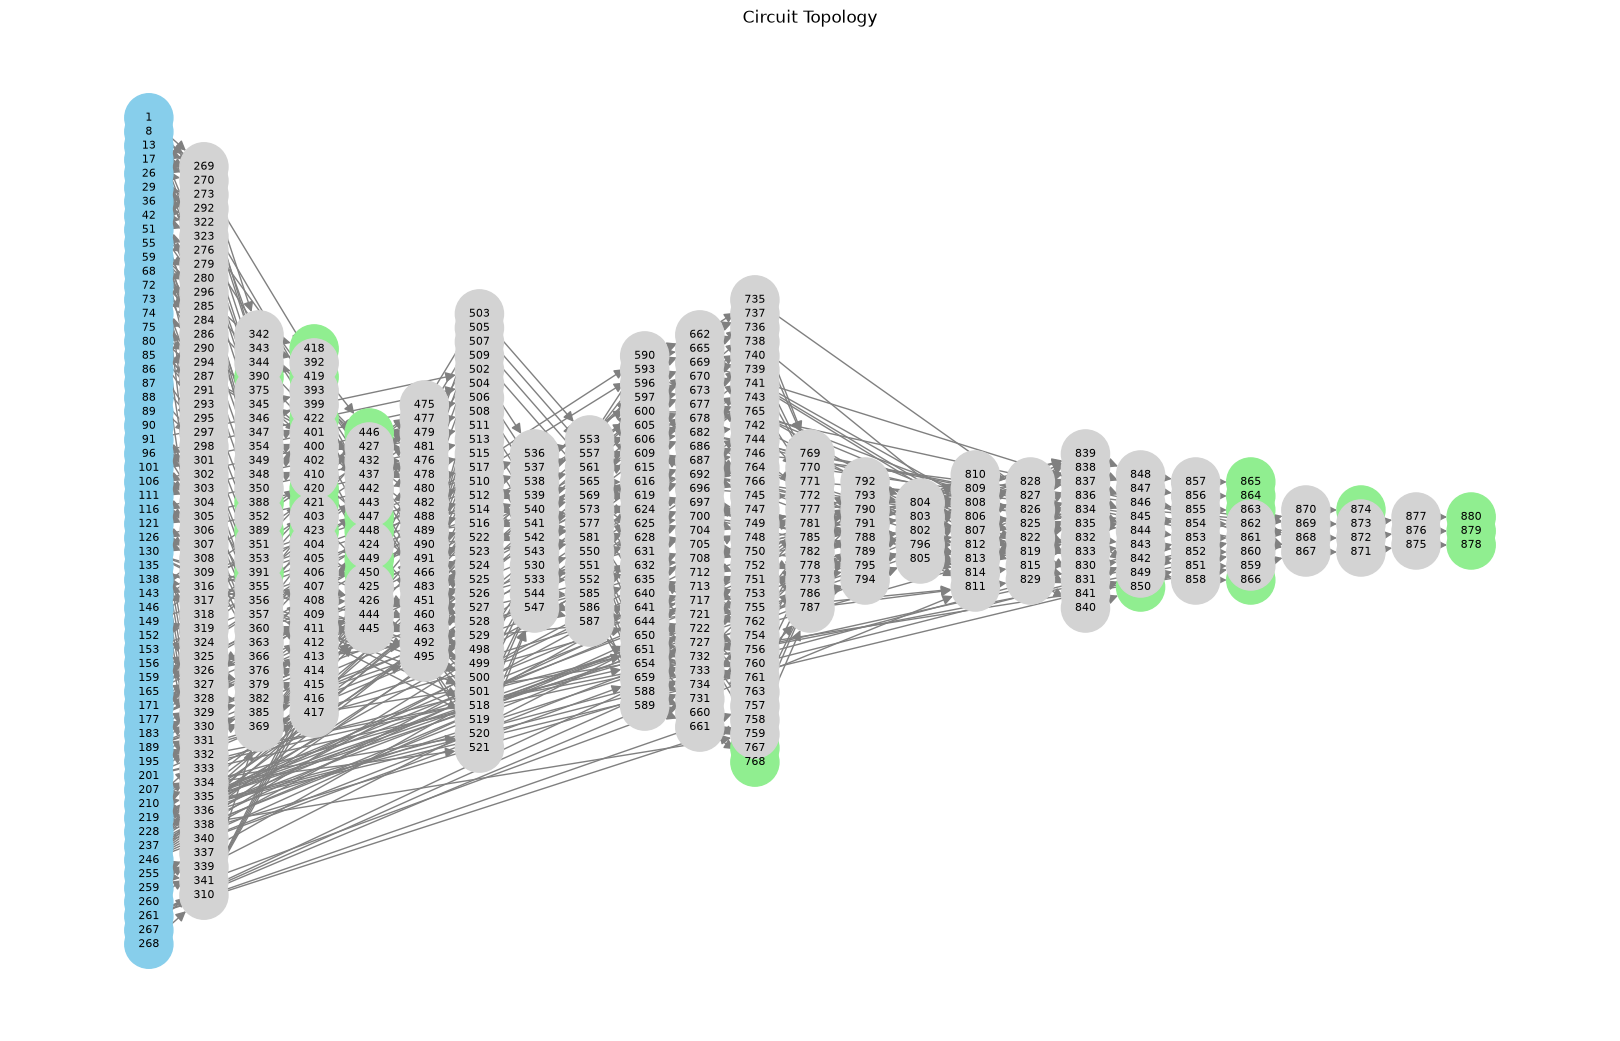

In [42]:
circuit.plot()

In [43]:
impact=circuit.analyze()

In [44]:
impact

,rank,signal,gate,level,fanout,PO_count,PO_impact,PO_impact_%,reachable_POs
0,1,1,NaN,0,6,15,0.576923,57.692308,"[418, 419, 446, 447, 448, 449, 850, 863, 864, ..."
1,2,29,NaN,0,6,15,0.576923,57.692308,"[388, 389, 390, 419, 446, 448, 850, 863, 864, ..."
2,3,42,NaN,0,8,14,0.538462,53.846154,"[388, 390, 419, 422, 446, 850, 863, 864, 865, ..."
3,4,59,NaN,0,8,13,0.500000,50.000000,"[420, 421, 422, 449, 850, 863, 864, 865, 866, ..."
4,5,13,NaN,0,3,13,0.500000,50.000000,"[418, 419, 446, 448, 449, 850, 863, 864, 865, ..."
...,...,...,...,...,...,...,...,...,...
438,439,866,BUFF,20,0,1,0.038462,3.846154,[866]
439,440,874,BUFF,22,0,1,0.038462,3.846154,[874]
440,441,878,BUFF,24,0,1,0.038462,3.846154,[878]
441,442,879,BUFF,24,0,1,0.038462,3.846154,[879]


In [45]:
info=circuit.signal_analysis("29")

In [46]:
info

{'signal': '29',
 'gate': None,
 'level': 0,
 'fanin': [],
 'fanout': ['273', '285', '287', '290', '291', '292'],
 'fanout_count': 6,
 'forward_cone': {'273',
  '285',
  '287',
  '290',
  '291',
  '292',
  '343',
  '344',
  '349',
  '388',
  '389',
  '390',
  '392',
  '401',
  '419',
  '432',
  '437',
  '446',
  '448',
  '476',
  '478',
  '480',
  '482',
  '488',
  '489',
  '490',
  '491',
  '503',
  '505',
  '507',
  '509',
  '553',
  '557',
  '561',
  '565',
  '569',
  '573',
  '577',
  '581',
  '590',
  '593',
  '596',
  '597',
  '600',
  '605',
  '606',
  '609',
  '615',
  '616',
  '619',
  '624',
  '625',
  '628',
  '631',
  '632',
  '635',
  '640',
  '641',
  '644',
  '650',
  '651',
  '654',
  '659',
  '662',
  '665',
  '669',
  '670',
  '673',
  '677',
  '678',
  '682',
  '686',
  '687',
  '692',
  '696',
  '697',
  '700',
  '704',
  '705',
  '708',
  '712',
  '713',
  '717',
  '721',
  '722',
  '727',
  '731',
  '732',
  '733',
  '734',
  '735',
  '736',
  '737',
  '738',
  '7

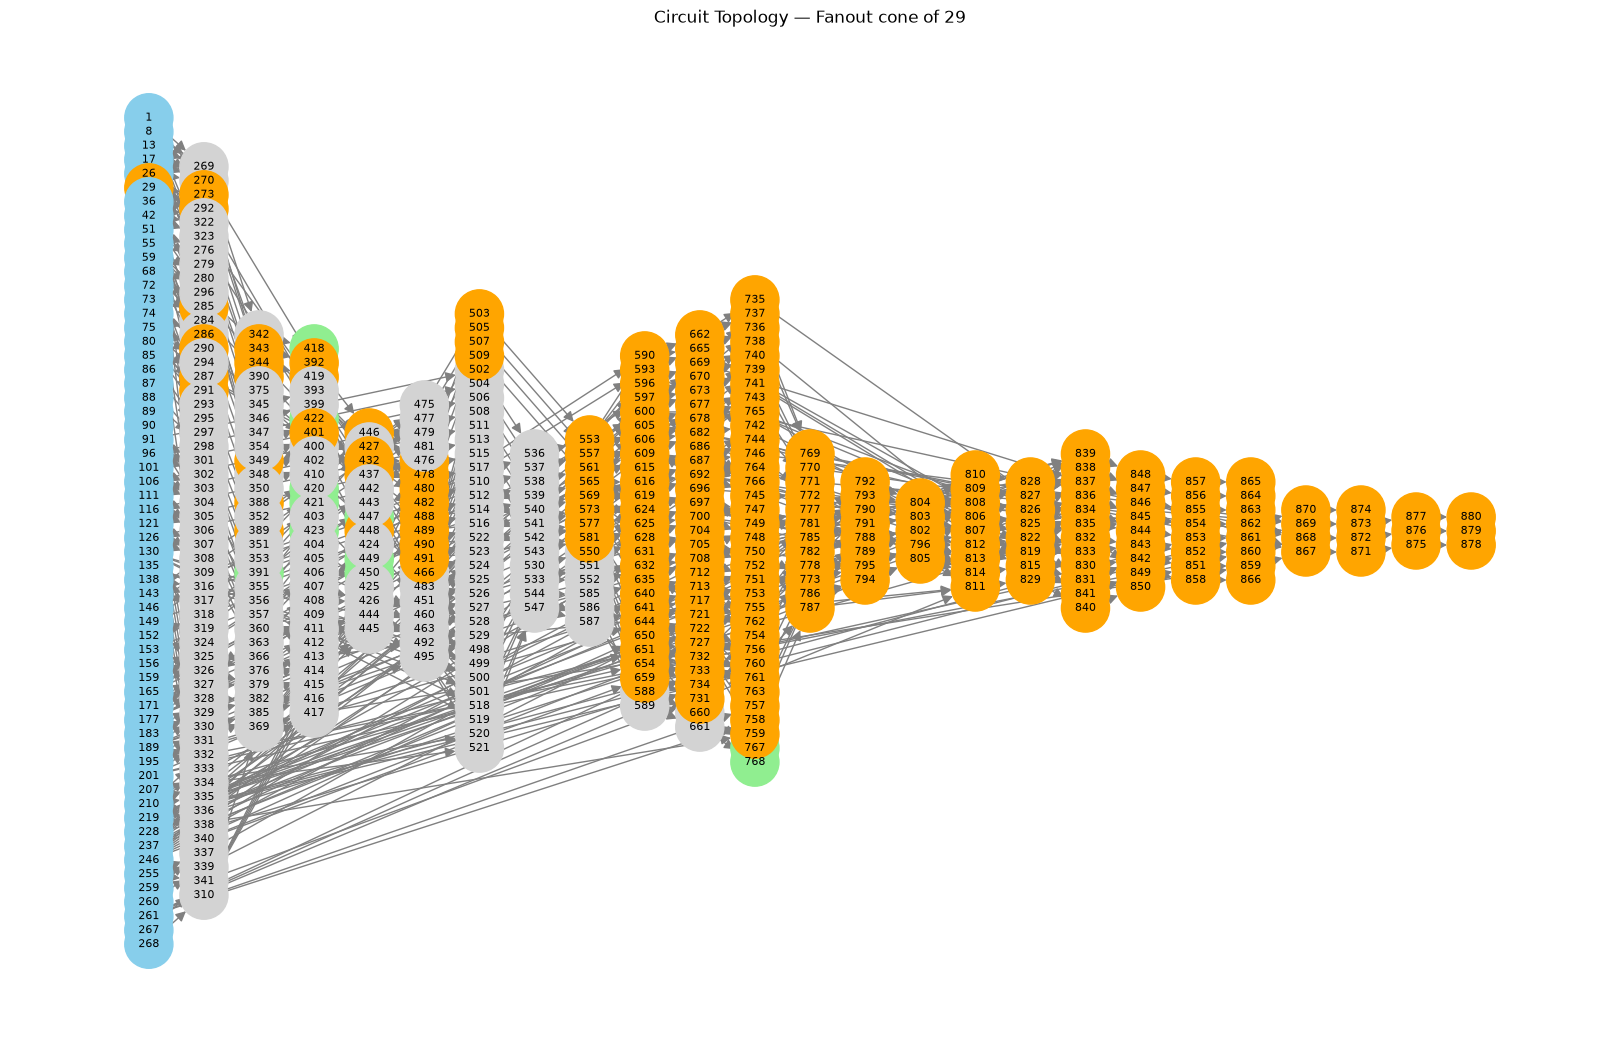

In [48]:
circuit.plot(signal="29")

SCOAP working code

In [61]:
from dataclasses import dataclass, field
from collections import deque
from typing import Dict, List, Tuple
import math
import re
import csv


# ============================================================
# Data structures
# ============================================================

@dataclass
class Gate:
    output: str
    type: str
    inputs: List[str] = field(default_factory=list)


@dataclass
class Node:
    name: str
    fanins: List[str] = field(default_factory=list)
    fanouts: List[str] = field(default_factory=list)

    # SCOAP values
    cc0: float = math.inf
    cc1: float = math.inf
    co: float = math.inf


# ============================================================
# BENCH Circuit
# ============================================================

class BenchCircuit:

    def __init__(self):
        self.nodes: Dict[str, Node] = {}
        self.gates: Dict[str, Gate] = {}

        self.primary_inputs: List[str] = []
        self.primary_outputs: List[str] = []

    def get_node(self, name: str) -> Node:
        if name not in self.nodes:
            self.nodes[name] = Node(name=name)

        return self.nodes[name]

    def add_gate(self, gate: Gate):

        self.gates[gate.output] = gate

        output_node = self.get_node(gate.output)

        output_node.fanins = list(gate.inputs)

        for inp in gate.inputs:

            input_node = self.get_node(inp)

            if gate.output not in input_node.fanouts:
                input_node.fanouts.append(gate.output)

    def parse(self, filename: str):

        with open(filename, "r") as f:

            for line_number, raw_line in enumerate(f, 1):

                # Remove comments
                line = raw_line.split("#", 1)[0].strip()

                if not line:
                    continue

                # ----------------------------------------------------
                # INPUT(...)
                # ----------------------------------------------------
                match = re.match(
                    r"^\s*INPUT\s*\(\s*([^)]+?)\s*\)\s*$",
                    line,
                    re.IGNORECASE,
                )

                if match:

                    name = match.group(1).strip()

                    self.get_node(name)

                    if name not in self.primary_inputs:
                        self.primary_inputs.append(name)

                    continue

                # ----------------------------------------------------
                # OUTPUT(...)
                # ----------------------------------------------------
                match = re.match(
                    r"^\s*OUTPUT\s*\(\s*([^)]+?)\s*\)\s*$",
                    line,
                    re.IGNORECASE,
                )

                if match:

                    name = match.group(1).strip()

                    self.get_node(name)

                    if name not in self.primary_outputs:
                        self.primary_outputs.append(name)

                    continue

                # ----------------------------------------------------
                # Gate:
                #
                # n1 = NAND(a, b)
                # ----------------------------------------------------
                match = re.match(
                    r"^\s*([A-Za-z0-9_$.\[\]-]+)\s*=\s*"
                    r"([A-Za-z0-9_]+)\s*\((.*?)\)\s*$",
                    line,
                    re.IGNORECASE,
                )

                if match:

                    output = match.group(1).strip()

                    gate_type = match.group(2).strip().upper()

                    args = match.group(3).strip()

                    inputs = (
                        [x.strip() for x in args.split(",")]
                        if args
                        else []
                    )

                    self.add_gate(
                        Gate(
                            output=output,
                            type=gate_type,
                            inputs=inputs,
                        )
                    )

                    continue

                raise ValueError(
                    f"Could not parse line {line_number}: "
                    f"{raw_line.rstrip()}"
                )

        self.validate()

    def validate(self):

        # Check POs
        for po in self.primary_outputs:

            if po not in self.nodes:
                raise ValueError(
                    f"Primary output '{po}' does not exist."
                )

        # Check gate inputs
        for output, gate in self.gates.items():

            for inp in gate.inputs:

                if inp not in self.nodes:
                    raise ValueError(
                        f"Gate '{output}' references "
                        f"undefined signal '{inp}'."
                    )

    def topological_order(self) -> List[str]:
        """
        Return nodes in topological order.

        Raises an error if the circuit contains
        a combinational loop.
        """

        indegree = {
            name: 0
            for name in self.nodes
        }

        for gate in self.gates.values():
            indegree[gate.output] = len(gate.inputs)

        queue = deque(
            name
            for name in self.nodes
            if indegree[name] == 0
        )

        order = []

        while queue:

            node = queue.popleft()

            order.append(node)

            for fanout in self.nodes[node].fanouts:

                indegree[fanout] -= 1

                if indegree[fanout] == 0:
                    queue.append(fanout)

        if len(order) != len(self.nodes):

            raise ValueError(
                "Circuit contains a combinational loop."
            )

        return order


# ============================================================
# SCOAP Analyzer
# ============================================================

class SCOAP:

    def __init__(self, circuit: BenchCircuit):

        self.circuit = circuit

        self.order = circuit.topological_order()

    # ========================================================
    # Controllability
    # ========================================================

    def calculate_controllability(self):

        nodes = self.circuit.nodes
        gates = self.circuit.gates

        # Primary inputs
        for pi in self.circuit.primary_inputs:

            nodes[pi].cc0 = 1
            nodes[pi].cc1 = 1

        # Forward topological traversal
        for signal in self.order:

            if signal in self.circuit.primary_inputs:
                continue

            if signal not in gates:
                continue

            gate = gates[signal]

            inputs = [
                nodes[x]
                for x in gate.inputs
            ]

            gate_type = gate.type

            # ----------------------------------------------------
            # BUF
            # ----------------------------------------------------
            if gate_type in ("BUFF", "BUFFER"):

                nodes[signal].cc0 = inputs[0].cc0 + 1
                nodes[signal].cc1 = inputs[0].cc1 + 1

            # ----------------------------------------------------
            # NOT
            # ----------------------------------------------------
            elif gate_type == "NOT":

                nodes[signal].cc0 = inputs[0].cc1 + 1
                nodes[signal].cc1 = inputs[0].cc0 + 1

            # ----------------------------------------------------
            # AND
            # ----------------------------------------------------
            elif gate_type == "AND":

                nodes[signal].cc0 = (
                    min(x.cc0 for x in inputs) + 1
                )

                nodes[signal].cc1 = (
                    sum(x.cc1 for x in inputs) + 1
                )

            # ----------------------------------------------------
            # NAND
            # ----------------------------------------------------
            elif gate_type == "NAND":

                nodes[signal].cc0 = (
                    sum(x.cc1 for x in inputs) + 1
                )

                nodes[signal].cc1 = (
                    min(x.cc0 for x in inputs) + 1
                )

            # ----------------------------------------------------
            # OR
            # ----------------------------------------------------
            elif gate_type == "OR":

                nodes[signal].cc0 = (
                    sum(x.cc0 for x in inputs) + 1
                )

                nodes[signal].cc1 = (
                    min(x.cc1 for x in inputs) + 1
                )

            # ----------------------------------------------------
            # NOR
            # ----------------------------------------------------
            elif gate_type == "NOR":

                nodes[signal].cc0 = (
                    min(x.cc1 for x in inputs) + 1
                )

                nodes[signal].cc1 = (
                    sum(x.cc0 for x in inputs) + 1
                )

            # ----------------------------------------------------
            # XOR
            # ----------------------------------------------------
            elif gate_type == "XOR":

                (
                    nodes[signal].cc0,
                    nodes[signal].cc1,
                ) = self._xor_controllability(inputs)

            # ----------------------------------------------------
            # XNOR
            # ----------------------------------------------------
            elif gate_type == "XNOR":

                cc0, cc1 = self._xor_controllability(inputs)

                nodes[signal].cc0 = cc1
                nodes[signal].cc1 = cc0

            else:

                raise NotImplementedError(
                    f"Unsupported gate type: {gate_type}"
                )

    def _xor_controllability(
        self,
        inputs: List[Node],
    ) -> Tuple[float, float]:

        if len(inputs) == 1:

            return (
                inputs[0].cc1 + 1,
                inputs[0].cc0 + 1,
            )

        cc0 = inputs[0].cc0
        cc1 = inputs[0].cc1

        for x in inputs[1:]:

            new_cc0 = min(
                cc0 + x.cc0,
                cc1 + x.cc1,
            ) + 1

            new_cc1 = min(
                cc0 + x.cc1,
                cc1 + x.cc0,
            ) + 1

            cc0 = new_cc0
            cc1 = new_cc1

        return cc0, cc1

    # ========================================================
    # Observability
    # ========================================================

    def calculate_observability(self):

        nodes = self.circuit.nodes
        gates = self.circuit.gates

        # Primary outputs
        for po in self.circuit.primary_outputs:
            nodes[po].co = 0

        # Reverse topological traversal
        for signal in reversed(self.order):

            if signal not in gates:
                continue

            gate = gates[signal]

            output = nodes[signal]

            if math.isinf(output.co):
                continue

            inputs = [
                nodes[x]
                for x in gate.inputs
            ]

            gate_type = gate.type

            # ----------------------------------------------------
            # BUF / NOT
            # ----------------------------------------------------
            if gate_type in ("BUFF", "BUFFER", "NOT"):

                inputs[0].co = min(
                    inputs[0].co,
                    output.co + 1,
                )

            # ----------------------------------------------------
            # AND / NAND
            # ----------------------------------------------------
            elif gate_type in ("AND", "NAND"):

                for i, inp in enumerate(inputs):

                    other_inputs = [
                        x
                        for j, x in enumerate(inputs)
                        if j != i
                    ]

                    side_cost = sum(
                        x.cc1
                        for x in other_inputs
                    )

                    candidate = (
                        output.co
                        + side_cost
                        + 1
                    )

                    inp.co = min(
                        inp.co,
                        candidate,
                    )

            # ----------------------------------------------------
            # OR / NOR
            # ----------------------------------------------------
            elif gate_type in ("OR", "NOR"):

                for i, inp in enumerate(inputs):

                    other_inputs = [
                        x
                        for j, x in enumerate(inputs)
                        if j != i
                    ]

                    side_cost = sum(
                        x.cc0
                        for x in other_inputs
                    )

                    candidate = (
                        output.co
                        + side_cost
                        + 1
                    )

                    inp.co = min(
                        inp.co,
                        candidate,
                    )

            # ----------------------------------------------------
            # XOR / XNOR
            # ----------------------------------------------------
            elif gate_type in ("XOR", "XNOR"):

                self._xor_observability(
                    inputs,
                    output.co,
                )

            else:

                raise NotImplementedError(
                    f"Unsupported gate type: {gate_type}"
                )

    def _xor_observability(
        self,
        inputs: List[Node],
        output_co: float,
    ):

        for i, inp in enumerate(inputs):

            other_inputs = [
                x
                for j, x in enumerate(inputs)
                if j != i
            ]

            side_cost = sum(
                min(x.cc0, x.cc1)
                for x in other_inputs
            )

            candidate = (
                output_co
                + side_cost
                + 1
            )

            inp.co = min(
                inp.co,
                candidate,
            )

    # ========================================================
    # Run complete SCOAP
    # ========================================================

    def calculate(self):

        self.calculate_controllability()

        self.calculate_observability()

        return self

    # ========================================================
    # Derived metrics
    # ========================================================

    @staticmethod
    def cc_average(node: Node):

        if math.isinf(node.cc0) or math.isinf(node.cc1):
            return math.inf

        return (node.cc0 + node.cc1) / 2

    @staticmethod
    def testability(node: Node):

        cc = SCOAP.cc_average(node)

        if math.isinf(cc) or math.isinf(node.co):
            return math.inf

        return cc + node.co


# ============================================================
# Convenience functions
# ============================================================

def node_type(circuit: BenchCircuit, name: str):

    if name in circuit.primary_inputs:
        return "PI"

    if name in circuit.primary_outputs:
        return "PO"

    if name in circuit.gates:
        return circuit.gates[name].type

    return "WIRE"


def scoap_table(circuit: BenchCircuit):

    rows = []

    for name, node in circuit.nodes.items():

        rows.append({
            "signal": name,
            "type": node_type(circuit, name),
            "CC0": node.cc0,
            "CC1": node.cc1,
            "CO": node.co,
            "CC_avg": SCOAP.cc_average(node),
            "Testability": SCOAP.testability(node),
            "is_PI": name in circuit.primary_inputs,
            "is_PO": name in circuit.primary_outputs,
        })

    return rows


def print_scoap(circuit: BenchCircuit):

    print("=" * 90)
    print("SCOAP RESULTS")
    print("=" * 90)

    print(f"Primary inputs : {len(circuit.primary_inputs)}")
    print(f"Primary outputs: {len(circuit.primary_outputs)}")
    print(f"Signals        : {len(circuit.nodes)}")
    print(f"Gates          : {len(circuit.gates)}")
    print()

    print(
        f"{'Signal':<18}"
        f"{'Type':<10}"
        f"{'CC0':>8}"
        f"{'CC1':>8}"
        f"{'CO':>8}"
        f"{'CC_avg':>10}"
        f"{'Test':>10}"
    )

    print("-" * 90)

    for name, node in circuit.nodes.items():

        cc = SCOAP.cc_average(node)
        test = SCOAP.testability(node)

        def fmt(x):
            return "INF" if math.isinf(x) else f"{x:.2f}"

        print(
            f"{name:<18}"
            f"{node_type(circuit, name):<10}"
            f"{fmt(node.cc0):>8}"
            f"{fmt(node.cc1):>8}"
            f"{fmt(node.co):>8}"
            f"{fmt(cc):>10}"
            f"{fmt(test):>10}"
        )


def rank_signals(
    circuit: BenchCircuit,
    metric="testability",
    ascending=True,
    top_n=10,
):

    nodes = list(circuit.nodes.values())

    if metric == "CC":

        key = SCOAP.cc_average

    elif metric == "CO":

        key = lambda n: n.co

    elif metric == "CC0":

        key = lambda n: n.cc0

    elif metric == "CC1":

        key = lambda n: n.cc1

    elif metric == "testability":

        key = SCOAP.testability

    else:

        raise ValueError(
            "metric must be one of: "
            "CC, CC0, CC1, CO, testability"
        )

    nodes.sort(
        key=key,
        reverse=not ascending,
    )

    return nodes[:top_n]


def print_ranking(
    circuit,
    metric="testability",
    ascending=True,
    top_n=10,
):

    ranked = rank_signals(
        circuit,
        metric=metric,
        ascending=ascending,
        top_n=top_n,
    )

    direction = (
        "lowest"
        if ascending
        else "highest"
    )

    print()
    print("=" * 70)
    print(
        f"TOP {top_n} SIGNALS — "
        f"{direction} {metric}"
    )
    print("=" * 70)

    for rank, node in enumerate(ranked, 1):

        print(
            f"{rank:>3}. "
            f"{node.name:<18} "
            f"CC0={node.cc0:<6.1f} "
            f"CC1={node.cc1:<6.1f} "
            f"CO={node.co:<6.1f} "
            f"CCavg={SCOAP.cc_average(node):<6.1f} "
            f"Test={SCOAP.testability(node):<6.1f}"
        )


def export_csv(circuit: BenchCircuit, filename: str):

    rows = scoap_table(circuit)

    with open(filename, "w", newline="") as f:

        writer = csv.DictWriter(
            f,
            fieldnames=rows[0].keys(),
        )

        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved: {filename}")


In [62]:
BENCH_FILE = "./data.nogit/c880.bench"

circuit = BenchCircuit()
circuit.parse(BENCH_FILE)

print("Circuit loaded successfully!")
print()
print("PIs :", circuit.primary_inputs)
print("POs :", circuit.primary_outputs)
print("Number of signals:", len(circuit.nodes))
print("Number of gates:", len(circuit.gates))


Circuit loaded successfully!

PIs : ['1', '8', '13', '17', '26', '29', '36', '42', '51', '55', '59', '68', '72', '73', '74', '75', '80', '85', '86', '87', '88', '89', '90', '91', '96', '101', '106', '111', '116', '121', '126', '130', '135', '138', '143', '146', '149', '152', '153', '156', '159', '165', '171', '177', '183', '189', '195', '201', '207', '210', '219', '228', '237', '246', '255', '259', '260', '261', '267', '268']
POs : ['388', '389', '390', '391', '418', '419', '420', '421', '422', '423', '446', '447', '448', '449', '450', '767', '768', '850', '863', '864', '865', '866', '874', '878', '879', '880']
Number of signals: 443
Number of gates: 383


In [64]:
scoap = SCOAP(circuit)
scoap.calculate()

print_scoap(circuit)
export_csv(circuit,"SCOAP.md")

SCOAP RESULTS
Primary inputs : 60
Primary outputs: 26
Signals        : 443
Gates          : 383

Signal            Type           CC0     CC1      CO    CC_avg      Test
------------------------------------------------------------------------------------------
1                 PI            1.00    1.00    6.00      1.00      7.00
8                 PI            1.00    1.00    6.00      1.00      7.00
13                PI            1.00    1.00    6.00      1.00      7.00
17                PI            1.00    1.00    6.00      1.00      7.00
26                PI            1.00    1.00    6.00      1.00      7.00
29                PI            1.00    1.00    4.00      1.00      5.00
36                PI            1.00    1.00    4.00      1.00      5.00
42                PI            1.00    1.00    4.00      1.00      5.00
51                PI            1.00    1.00    6.00      1.00      7.00
55                PI            1.00    1.00   10.00      1.00     11.00
59       

Faults list

In [67]:
from dataclasses import dataclass
from collections import defaultdict, deque
import re
import csv
from pathlib import Path


# ============================================================
# 1. DATA STRUCTURES
# ============================================================

@dataclass(frozen=True)
class FaultSite:
    """
    A physical fault site.

    kind:
        'net'    -> ordinary net/stem
        'branch' -> individual fanout branch

    For a branch:
        net  = source net
        gate = destination gate
    """
    net: str
    kind: str = "net"
    gate: str = None

    def __str__(self):
        if self.kind == "branch":
            return f"{self.net}->{self.gate}"
        return self.net


@dataclass(frozen=True)
class Fault:
    site: FaultSite
    value: int

    def __str__(self):
        return f"{self.site}/SA{self.value}"


@dataclass
class Gate:
    name: str
    typ: str
    inputs: list
    output: str


# ============================================================
# 2. BENCH PARSER
# ============================================================

class BenchCircuit:
    """
    Parser and topology representation for ISCAS-style .bench files.

    Supported gate types:
        AND
        NAND
        OR
        NOR
        NOT
        BUFF
        XOR
        XNOR

    The parser also tolerates:
        INPUT(x)
        OUTPUT(x)

    and assignments such as:
        N1 = NAND(A, B)
    """

    SUPPORTED_GATES = {
        "AND", "NAND",
        "OR", "NOR",
        "NOT", "BUFF",
        "XOR", "XNOR"
    }

    def __init__(self):
        self.inputs = []
        self.outputs = []
        self.gates = {}
        self.net_drivers = {}
        self.fanout = defaultdict(list)

    # --------------------------------------------------------
    # Parse
    # --------------------------------------------------------

    @classmethod
    def from_file(cls, filename):
        circuit = cls()

        with open(filename, "r") as f:
            lines = f.readlines()

        for raw in lines:

            # Remove comments
            line = raw.split("#", 1)[0].strip()

            if not line:
                continue

            # INPUT(...)
            m = re.match(r"INPUT\s*\(\s*([^)]+)\s*\)", line,
                         flags=re.IGNORECASE)
            if m:
                name = m.group(1).strip()
                circuit.inputs.append(name)
                continue

            # OUTPUT(...)
            m = re.match(r"OUTPUT\s*\(\s*([^)]+)\s*\)", line,
                         flags=re.IGNORECASE)
            if m:
                name = m.group(1).strip()
                circuit.outputs.append(name)
                continue

            # gate assignment
            m = re.match(
                r"^\s*([A-Za-z0-9_$]+)\s*=\s*"
                r"([A-Za-z0-9_$]+)\s*\((.*)\)\s*$",
                line
            )

            if not m:
                continue

            output = m.group(1).strip()
            gate_type = m.group(2).strip().upper()
            arg_string = m.group(3).strip()

            if gate_type not in circuit.SUPPORTED_GATES:
                raise ValueError(
                    f"Unsupported gate type '{gate_type}' "
                    f"in line: {raw.strip()}"
                )

            if arg_string:
                inputs = [
                    x.strip()
                    for x in arg_string.split(",")
                    if x.strip()
                ]
            else:
                inputs = []

            gate = Gate(
                name=output,
                typ=gate_type,
                inputs=inputs,
                output=output
            )

            circuit.gates[output] = gate

        circuit._build_topology()

        return circuit

    # --------------------------------------------------------
    # Topology
    # --------------------------------------------------------

    def _build_topology(self):

        self.net_drivers.clear()
        self.fanout.clear()

        # Every gate output has a driver
        for gate in self.gates.values():
            self.net_drivers[gate.output] = gate.name

            for inp in gate.inputs:
                self.fanout[inp].append(gate.name)

        # Primary inputs do not have gate drivers
        for pi in self.inputs:
            self.net_drivers[pi] = None

    # --------------------------------------------------------
    # Information
    # --------------------------------------------------------

    @property
    def nets(self):
        nets = set(self.inputs)

        for gate in self.gates.values():
            nets.add(gate.output)
            nets.update(gate.inputs)

        return sorted(nets)

    @property
    def fanout_stems(self):
        return sorted(
            net for net in self.nets
            if len(self.fanout.get(net, [])) > 1
        )

    def summary(self):

        print("=" * 60)
        print("CIRCUIT SUMMARY")
        print("=" * 60)

        print(f"Primary inputs : {len(self.inputs)}")
        print(f"Primary outputs: {len(self.outputs)}")
        print(f"Gates          : {len(self.gates)}")
        print(f"Nets           : {len(self.nets)}")
        print(f"Fanout stems   : {len(self.fanout_stems)}")

        print("\nGate types:")

        counts = defaultdict(int)

        for gate in self.gates.values():
            counts[gate.typ] += 1

        for typ in sorted(counts):
            print(f"  {typ:6s}: {counts[typ]}")

        print("\nFanout stems:")

        for net in self.fanout_stems:
            print(
                f"  {net}: "
                f"{len(self.fanout[net])} branches -> "
                f"{', '.join(self.fanout[net])}"
            )


# ============================================================
# 3. COMPLETE SINGLE STUCK-AT FAULT LIST
# ============================================================

class FaultListGenerator:

    def __init__(self, circuit):
        self.circuit = circuit

    # --------------------------------------------------------
    # Determine all physical fault sites
    # --------------------------------------------------------

    def physical_fault_sites(self):
        """
        Generate physical fault sites.

        Rule:
        - A non-fanout net is one fault site.
        - A fanout stem is one fault site.
        - Every branch leaving a fanout stem is an additional
          fault site.

        Therefore:

            non-fanout:
                N

            fanout:
                N_stem
                N_branch1
                N_branch2
                ...

        Primary output nets are also fault sites.
        """

        sites = []

        for net in self.circuit.nets:

            fanouts = self.circuit.fanout.get(net, [])

            # Stem always exists
            sites.append(
                FaultSite(
                    net=net,
                    kind="net"
                )
            )

            # Individual branches only when there is fanout
            if len(fanouts) > 1:

                for gate in sorted(fanouts):

                    sites.append(
                        FaultSite(
                            net=net,
                            kind="branch",
                            gate=gate
                        )
                    )

        return sites

    # --------------------------------------------------------
    # Complete SAF list
    # --------------------------------------------------------

    def complete_fault_list(self):

        faults = []

        for site in self.physical_fault_sites():

            faults.append(Fault(site, 0))
            faults.append(Fault(site, 1))

        return faults


# ============================================================
# 4. FAULT COLLAPSING ENGINE
# ============================================================

class FaultCollapser:

    """
    Gate-level single stuck-at fault collapsing.

    The implementation uses:

    1. Fault equivalence
    2. Fault dominance

    Standard collapsing relationships:

    AND:
        output SA0 <-> input SA0
        input SA1 dominates output SA1

    NAND:
        output SA1 <-> input SA0
        input SA1 dominates output SA0

    OR:
        output SA1 <-> input SA1
        input SA0 dominates output SA0

    NOR:
        output SA0 <-> input SA1
        input SA0 dominates output SA1

    BUF:
        input SA0 <-> output SA0
        input SA1 <-> output SA1

    NOT:
        input SA0 <-> output SA1
        input SA1 <-> output SA0

    XOR/XNOR:
        No ordinary single-line equivalence/dominance
        collapsing is applied.

    IMPORTANT:
        For fanout stems, the stem is NOT treated as
        equivalent to its branches.
    """

    def __init__(self, circuit):

        self.circuit = circuit

        generator = FaultListGenerator(circuit)

        self.all_faults = generator.complete_fault_list()

        self.fault_set = set(self.all_faults)

        # Union-find for equivalence
        self.parent = {
            fault: fault
            for fault in self.all_faults
        }

        # Dominance relation:
        #
        # dominated_fault -> dominating_fault
        #
        # If A dominates B, detecting A guarantees detection
        # of B under the usual fault-collapsing interpretation.
        self.dominance = defaultdict(set)

    # --------------------------------------------------------
    # Union-find
    # --------------------------------------------------------

    def find(self, x):

        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])

        return self.parent[x]

    def union(self, a, b):

        ra = self.find(a)
        rb = self.find(b)

        if ra != rb:
            self.parent[rb] = ra

    # --------------------------------------------------------
    # Helper
    # --------------------------------------------------------

    def _net_site(self, net):
        return FaultSite(net=net, kind="net")

    def _branch_site(self, net, gate):
        return FaultSite(
            net=net,
            kind="branch",
            gate=gate
        )

    def _fault(self, site, value):
        return Fault(site, value)

    # --------------------------------------------------------
    # Determine whether an input connection is a branch
    # --------------------------------------------------------

    def input_site(self, net, gate_name):

        fanouts = self.circuit.fanout.get(net, [])

        if len(fanouts) > 1:

            return self._branch_site(
                net,
                gate_name
            )

        return self._net_site(net)

    # --------------------------------------------------------
    # Equivalence helper
    # --------------------------------------------------------

    def add_equivalence(self, a, b):

        if a in self.fault_set and b in self.fault_set:
            self.union(a, b)

    # --------------------------------------------------------
    # Dominance helper
    # --------------------------------------------------------

    def add_dominance(self, dominated, dominating):

        if (
            dominated in self.fault_set
            and dominating in self.fault_set
        ):
            self.dominance[dominated].add(dominating)

    # --------------------------------------------------------
    # Gate collapsing rules
    # --------------------------------------------------------

    def process_gate(self, gate):

        typ = gate.typ

        output_site = self._net_site(gate.output)

        input_sites = [
            self.input_site(inp, gate.name)
            for inp in gate.inputs
        ]

        # ====================================================
        # AND
        # ====================================================

        if typ == "AND":

            # Output SA0 equivalent to every input SA0
            output_sa0 = self._fault(output_site, 0)

            for inp_site in input_sites:

                input_sa0 = self._fault(inp_site, 0)

                self.add_equivalence(
                    output_sa0,
                    input_sa0
                )

            # Input SA1 dominates output SA1
            output_sa1 = self._fault(output_site, 1)

            for inp_site in input_sites:

                input_sa1 = self._fault(inp_site, 1)

                self.add_dominance(
                    output_sa1,
                    input_sa1
                )

        # ====================================================
        # NAND
        # ====================================================

        elif typ == "NAND":

            # Output SA1 equivalent to every input SA0
            output_sa1 = self._fault(output_site, 1)

            for inp_site in input_sites:

                input_sa0 = self._fault(inp_site, 0)

                self.add_equivalence(
                    output_sa1,
                    input_sa0
                )

            # Input SA1 dominates output SA0
            output_sa0 = self._fault(output_site, 0)

            for inp_site in input_sites:

                input_sa1 = self._fault(inp_site, 1)

                self.add_dominance(
                    output_sa0,
                    input_sa1
                )

        # ====================================================
        # OR
        # ====================================================

        elif typ == "OR":

            # Output SA1 equivalent to every input SA1
            output_sa1 = self._fault(output_site, 1)

            for inp_site in input_sites:

                input_sa1 = self._fault(inp_site, 1)

                self.add_equivalence(
                    output_sa1,
                    input_sa1
                )

            # Input SA0 dominates output SA0
            output_sa0 = self._fault(output_site, 0)

            for inp_site in input_sites:

                input_sa0 = self._fault(inp_site, 0)

                self.add_dominance(
                    output_sa0,
                    input_sa0
                )

        # ====================================================
        # NOR
        # ====================================================

        elif typ == "NOR":

            # Output SA0 equivalent to every input SA1
            output_sa0 = self._fault(output_site, 0)

            for inp_site in input_sites:

                input_sa1 = self._fault(inp_site, 1)

                self.add_equivalence(
                    output_sa0,
                    input_sa1
                )

            # Input SA0 dominates output SA1
            output_sa1 = self._fault(output_site, 1)

            for inp_site in input_sites:

                input_sa0 = self._fault(inp_site, 0)

                self.add_dominance(
                    output_sa1,
                    input_sa0
                )

        # ====================================================
        # BUF
        # ====================================================

        elif typ == "BUF":

            if len(input_sites) != 1:
                raise ValueError(
                    f"BUF gate {gate.name} must have one input"
                )

            inp = input_sites[0]

            self.add_equivalence(
                self._fault(output_site, 0),
                self._fault(inp, 0)
            )

            self.add_equivalence(
                self._fault(output_site, 1),
                self._fault(inp, 1)
            )

        # ====================================================
        # NOT
        # ====================================================

        elif typ == "NOT":

            if len(input_sites) != 1:
                raise ValueError(
                    f"NOT gate {gate.name} must have one input"
                )

            inp = input_sites[0]

            self.add_equivalence(
                self._fault(output_site, 0),
                self._fault(inp, 1)
            )

            self.add_equivalence(
                self._fault(output_site, 1),
                self._fault(inp, 0)
            )

        # ====================================================
        # XOR / XNOR
        # ====================================================

        elif typ in ("XOR", "XNOR"):

            # No simple structural equivalence/dominance
            # collapsing is applied.
            pass

    # --------------------------------------------------------
    # Build equivalence classes
    # --------------------------------------------------------

    def build(self):

        for gate in self.circuit.gates.values():
            self.process_gate(gate)

    # --------------------------------------------------------
    # Equivalence classes
    # --------------------------------------------------------

    def equivalence_classes(self):

        classes = defaultdict(list)

        for fault in self.all_faults:

            root = self.find(fault)
            classes[root].append(fault)

        return dict(classes)

    # --------------------------------------------------------
    # Select representative
    # --------------------------------------------------------

    @staticmethod
    def representative(faults):

        # Prefer:
        #   1. stem over branch
        #   2. lexical net name
        #   3. SA value

        return sorted(
            faults,
            key=lambda f: (
                0 if f.site.kind == "net" else 1,
                str(f.site),
                f.value
            )
        )[0]

    # --------------------------------------------------------
    # Collapsed list after equivalence
    # --------------------------------------------------------

    def equivalence_collapsed_faults(self):

        classes = self.equivalence_classes()

        reps = []

        for faults in classes.values():

            reps.append(
                self.representative(faults)
            )

        return sorted(
            reps,
            key=str
        )

    # --------------------------------------------------------
    # Dominance collapsing
    # --------------------------------------------------------

    def dominance_collapsed_faults(self):

        """
        Perform equivalence collapsing first.

        Then remove faults that are dominated by another
        representative.

        A dominance relation is mapped through equivalence
        classes.
        """

        eq_classes = self.equivalence_classes()

        representatives = {
            self.find(f): self.representative(members)
            for f, members in eq_classes.items()
        }

        # Start with one representative per equivalence class
        collapsed = set(representatives.values())

        # Convert dominance relations to representatives
        dominance_rep = defaultdict(set)

        for dominated, dominators in self.dominance.items():

            dominated_rep = representatives[
                self.find(dominated)
            ]

            for dominating in dominators:

                dominating_rep = representatives[
                    self.find(dominating)
                ]

                if dominated_rep != dominating_rep:

                    dominance_rep[
                        dominated_rep
                    ].add(dominating_rep)

        # ----------------------------------------------------
        # Remove dominated faults.
        #
        # Important:
        # If A dominates B, B can be removed from a fault
        # test set when A is retained.
        # ----------------------------------------------------

        removed = set()

        for dominated, dominators in dominance_rep.items():

            for dominating in dominators:

                if dominating in collapsed:
                    removed.add(dominated)
                    break

        collapsed -= removed

        return sorted(
            collapsed,
            key=str
        )

    # --------------------------------------------------------
    # Generate everything
    # --------------------------------------------------------

    def generate(self):

        self.build()

        complete = list(self.all_faults)

        equivalence = self.equivalence_collapsed_faults()

        collapsed = self.dominance_collapsed_faults()

        return {
            "complete": sorted(complete, key=str),
            "equivalence_collapsed": equivalence,
            "collapsed": collapsed,
            "equivalence_classes": self.equivalence_classes(),
            "dominance": dict(self.dominance)
        }


# ============================================================
# 5. REPORTING
# ============================================================

def print_fault_statistics(results):

    complete = results["complete"]
    eq = results["equivalence_collapsed"]
    collapsed = results["collapsed"]

    print("=" * 70)
    print("SINGLE STUCK-AT FAULT STATISTICS")
    print("=" * 70)

    print(f"Complete fault count             : {len(complete)}")
    print(f"After equivalence collapsing     : {len(eq)}")
    print(f"After dominance collapsing       : {len(collapsed)}")

    print()

    if complete:
        eq_reduction = (
            100.0 *
            (1.0 - len(eq) / len(complete))
        )

        final_reduction = (
            100.0 *
            (1.0 - len(collapsed) / len(complete))
        )

        print(
            f"Equivalence reduction            : "
            f"{eq_reduction:.2f}%"
        )

        print(
            f"Total collapsing reduction       : "
            f"{final_reduction:.2f}%"
        )

    print("=" * 70)


def print_fault_list(faults, title):

    print()
    print("=" * 70)
    print(title)
    print("=" * 70)

    for i, fault in enumerate(faults, start=1):
        print(f"{i:6d}: {fault}")

    print(f"\nTotal: {len(faults)}")


# ============================================================
# 6. PRINT FANOUT INFORMATION
# ============================================================

def print_fanout_fault_sites(circuit):

    print()
    print("=" * 70)
    print("FANOUT FAULT SITES")
    print("=" * 70)

    for net in circuit.fanout_stems:

        branches = circuit.fanout[net]

        print(f"\nStem: {net}")

        print(f"  {net}/SA0")
        print(f"  {net}/SA1")

        for gate in sorted(branches):

            print(f"  {net}->{gate}/SA0")
            print(f"  {net}->{gate}/SA1")


# ============================================================
# 7. SAVE FAULT LIST
# ============================================================

def save_fault_list(faults, filename):

    with open(filename, "w") as f:

        for fault in faults:
            f.write(str(fault) + "\n")


def save_fault_csv(faults, filename):

    with open(
        filename,
        "w",
        newline=""
    ) as f:

        writer = csv.writer(f)

        writer.writerow([
            "fault_number",
            "net",
            "site_type",
            "gate",
            "stuck_at"
        ])

        for i, fault in enumerate(faults, start=1):

            writer.writerow([
                i,
                fault.site.net,
                fault.site.kind,
                fault.site.gate
                if fault.site.gate is not None
                else "",
                fault.value
            ])


# ============================================================
# 8. COMPLETE ANALYSIS FUNCTION
# ============================================================

def analyze_bench(
    bench_file,
    print_complete=True,
    print_equivalence=False,
    print_collapsed=True,
    save_files=False
):

    circuit = BenchCircuit.from_file(bench_file)

    circuit.summary()

    print_fanout_fault_sites(circuit)

    collapser = FaultCollapser(circuit)

    results = collapser.generate()

    print_fault_statistics(results)

    if print_complete:
        print_fault_list(
            results["complete"],
            "COMPLETE SINGLE STUCK-AT FAULT LIST"
        )

    if print_equivalence:
        print_fault_list(
            results["equivalence_collapsed"],
            "EQUIVALENCE-COLLAPSED FAULT LIST"
        )

    if print_collapsed:
        print_fault_list(
            results["collapsed"],
            "FINAL COLLAPSED SINGLE STUCK-AT FAULT LIST"
        )

    if save_files:

        stem = Path(bench_file).stem

        save_fault_list(
            results["complete"],
            f"{stem}_complete_saf.txt"
        )

        save_fault_list(
            results["equivalence_collapsed"],
            f"{stem}_equivalence_collapsed_saf.txt"
        )

        save_fault_list(
            results["collapsed"],
            f"{stem}_collapsed_saf.txt"
        )

        save_fault_csv(
            results["complete"],
            f"{stem}_complete_saf.csv"
        )

        save_fault_csv(
            results["collapsed"],
            f"{stem}_collapsed_saf.csv"
        )

        print("\nFault files written to current directory.")

    return circuit, results


In [70]:
circuit, results = analyze_bench(
    "./data.nogit/c880.bench",
    print_complete=True,
    print_equivalence=True,
    print_collapsed=True,
    save_files=True
)


CIRCUIT SUMMARY
Primary inputs : 60
Primary outputs: 26
Gates          : 383
Nets           : 443
Fanout stems   : 125

Gate types:
  AND   : 117
  BUFF  : 26
  NAND  : 87
  NOR   : 61
  NOT   : 63
  OR    : 29

Fanout stems:
  1: 6 branches -> 269, 270, 276, 279, 280, 483
  101: 4 branches -> 303, 304, 334, 506
  106: 4 branches -> 303, 304, 335, 508
  111: 4 branches -> 305, 306, 336, 511
  116: 4 branches -> 305, 306, 338, 513
  121: 4 branches -> 307, 308, 340, 515
  126: 3 branches -> 307, 308, 517
  13: 3 branches -> 269, 270, 280
  130: 4 branches -> 498, 499, 518, 519
  135: 2 branches -> 500, 501
  138: 4 branches -> 309, 316, 317, 318
  143: 2 branches -> 475, 510
  146: 2 branches -> 477, 512
  149: 2 branches -> 479, 514
  153: 2 branches -> 481, 516
  156: 2 branches -> 319, 442
  159: 5 branches -> 324, 325, 522, 590, 593
  165: 5 branches -> 324, 325, 523, 597, 600
  17: 8 branches -> 269, 270, 279, 317, 322, 323, 432, 443
  171: 5 branches -> 326, 327, 524, 606, 609
  1